In [1]:
import kagglehub
path = kagglehub.dataset_download("rohitdurbha/alibaba-cluster-data")

Using Colab cache for faster access to the 'alibaba-cluster-data' dataset.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import glob
import os

In [3]:
# Find all CSV files
found_csv_files = glob.glob(os.path.join(path, '**', '*.csv'), recursive=True)

# Filter specifically for batch_instance.csv
target_file = [f for f in found_csv_files if 'batch_instance.csv' in f][0]
data = pd.read_csv(target_file)

# Re-apply median imputation
for col in ['cpu_avg', 'cpu_max', 'mem_avg', 'mem_max']:
    if data[col].isnull().any():
        median_val = data[col].median()
        data[col] = data[col].fillna(median_val)

print(f"Successfully loaded and preprocessed: {os.path.basename(target_file)}")

Successfully loaded and preprocessed: batch_instance.csv


In [4]:
print(f"Numbers of Rows: {data.shape[0]}")
print(f"Numbers of Columns: {data.shape[1]}")

Numbers of Rows: 15000000
Numbers of Columns: 14


In [5]:
data.head()

,instance_name,task_name,job_name,task_type,status,start_time,end_time,machine_id,seq_no,total_seq_no,cpu_avg,cpu_max,mem_avg,mem_max
0,ins_74901673,task_LTg0MTUwNTA5Mjg4MDkwNjIzMA==,j_217,10,Terminated,673795,673797,m_2637,1,1,13.0,16.0,0.02,0.02
1,ins_815802872,M1,j_1527,1,Terminated,158478,158520,m_3430,1,1,3.0,19.0,0.13,0.18
2,ins_564677701,M1,j_2014,1,Terminated,372602,372616,m_1910,1,1,87.0,116.0,0.04,0.05
3,ins_257566161,M1,j_2014,1,Terminated,372602,372615,m_2485,1,1,91.0,123.0,0.05,0.05
4,ins_688679908,M1,j_2014,1,Terminated,372602,372615,m_993,1,1,93.0,141.0,0.05,0.05


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000000 entries, 0 to 14999999
Data columns (total 14 columns):
 #   Column         Dtype  
---  ------         -----  
 0   instance_name  object 
 1   task_name      object 
 2   job_name       object 
 3   task_type      int64  
 4   status         object 
 5   start_time     int64  
 6   end_time       int64  
 7   machine_id     object 
 8   seq_no         int64  
 9   total_seq_no   int64  
 10  cpu_avg        float64
 11  cpu_max        float64
 12  mem_avg        float64
 13  mem_max        float64
dtypes: float64(4), int64(5), object(5)
memory usage: 1.6+ GB


In [7]:
data.describe()

,task_type,start_time,end_time,seq_no,total_seq_no,cpu_avg,cpu_max,mem_avg,mem_max
count,1.500000e+07,1.500000e+07,1.500000e+07,1.500000e+07,1.500000e+07,1.500000e+07,1.500000e+07,1.500000e+07,1.500000e+07
mean,1.176012e+00,3.844798e+05,3.840417e+05,1.000174e+00,1.000429e+00,6.104746e+01,1.212906e+02,1.015143e-01,1.276815e-01
std,1.075984e+00,1.786461e+05,1.790655e+05,1.370778e-02,2.206845e-02,3.230257e+01,1.139062e+02,2.410931e-01,3.000903e-01
min,1.000000e+00,8.599700e+04,0.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.000000e+00,2.288030e+05,2.275430e+05,1.000000e+00,1.000000e+00,3.800000e+01,7.500000e+01,3.000000e-02,3.000000e-02
50%,1.000000e+00,3.702025e+05,3.696320e+05,1.000000e+00,1.000000e+00,6.300000e+01,9.500000e+01,4.000000e-02,5.000000e-02
75%,1.000000e+00,5.460230e+05,5.455560e+05,1.000000e+00,1.000000e+00,8.300000e+01,1.280000e+02,8.000000e-02,1.000000e-01
max,1.200000e+01,6.911970e+05,7.506770e+05,4.000000e+00,4.000000e+00,5.603000e+03,8.295000e+03,2.807000e+01,5.212000e+01


In [ ]:
print('Missing values per column:')
print(data.isnull().sum().sort_values(ascending=False))

Missing values per column:
instance_name    0
task_name        0
job_name         0
task_type        0
status           0
start_time       0
end_time         0
machine_id       0
seq_no           0
total_seq_no     0
cpu_avg          0
cpu_max          0
mem_avg          0
mem_max          0
dtype: int64


In [8]:
# Impute missing values with the median for numerical columns
for col in ['cpu_avg', 'cpu_max', 'mem_avg', 'mem_max']:
    if data[col].isnull().any():
        median_val = data[col].median()
        # Corrected: Assign the result back to the column instead of using inplace=True
        data[col] = data[col].fillna(median_val)
        print(f"Missing values in '{col}' imputed with median: {median_val}")

# Verify that there are no more missing values
print('\nMissing values after imputation:')
print(data.isnull().sum().sort_values(ascending=False))


Missing values after imputation:
instance_name    0
task_name        0
job_name         0
task_type        0
status           0
start_time       0
end_time         0
machine_id       0
seq_no           0
total_seq_no     0
cpu_avg          0
cpu_max          0
mem_avg          0
mem_max          0
dtype: int64


In [9]:
resource_usage_by_task_type = data.groupby('task_type')[['cpu_avg', 'cpu_max', 'mem_avg', 'mem_max']].mean()
display(resource_usage_by_task_type)

,cpu_avg,cpu_max,mem_avg,mem_max
task_type,,,,
1,61.599446,122.182454,0.102523,0.128812
3,77.301008,105.666321,0.040152,0.054229
4,11.511628,36.860465,0.037326,0.041860
5,63.000000,95.000000,0.040000,0.050000
6,15.531896,35.165846,0.020444,0.021226
7,63.000000,95.000000,0.040000,0.050000
8,48.883766,130.772220,0.135030,0.189773
9,83.730648,299.684982,0.168298,0.202371
10,72.348451,88.813193,0.052387,0.057618


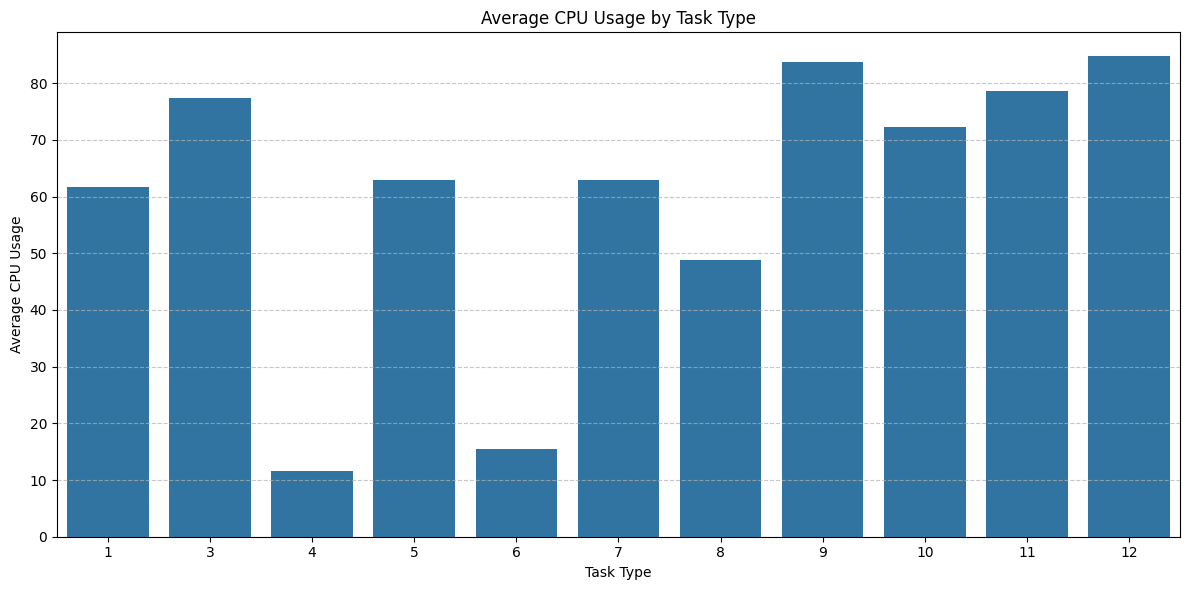

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(x=resource_usage_by_task_type.index, y='cpu_avg', data=resource_usage_by_task_type)
plt.title('Average CPU Usage by Task Type')
plt.xlabel('Task Type')
plt.ylabel('Average CPU Usage')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

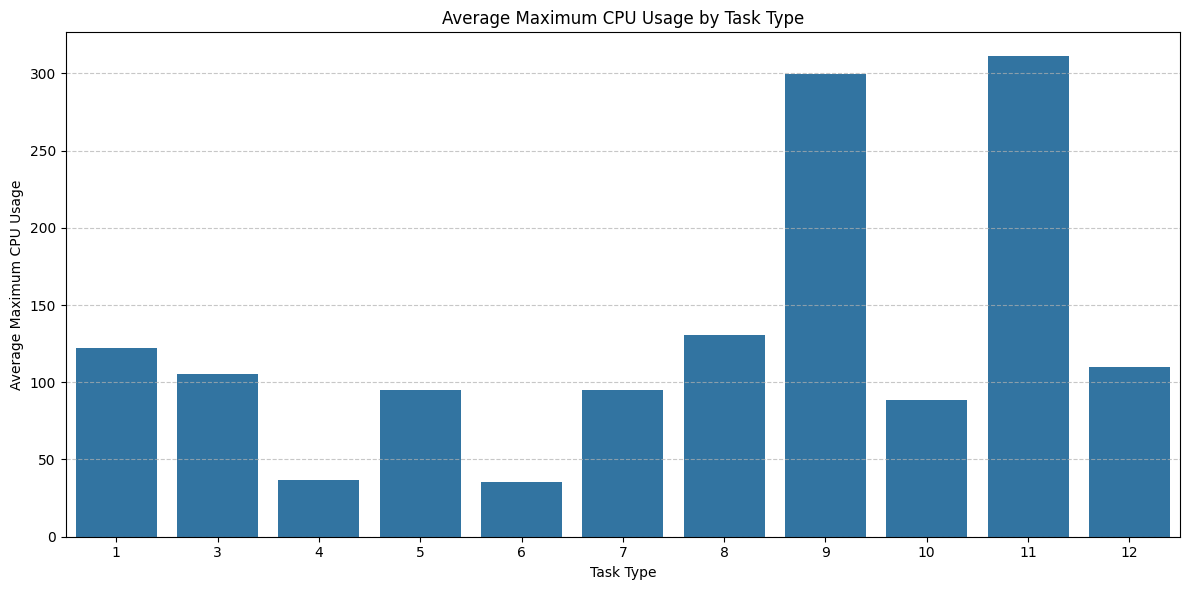

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(x=resource_usage_by_task_type.index, y='cpu_max', data=resource_usage_by_task_type)
plt.title('Average Maximum CPU Usage by Task Type')
plt.xlabel('Task Type')
plt.ylabel('Average Maximum CPU Usage')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

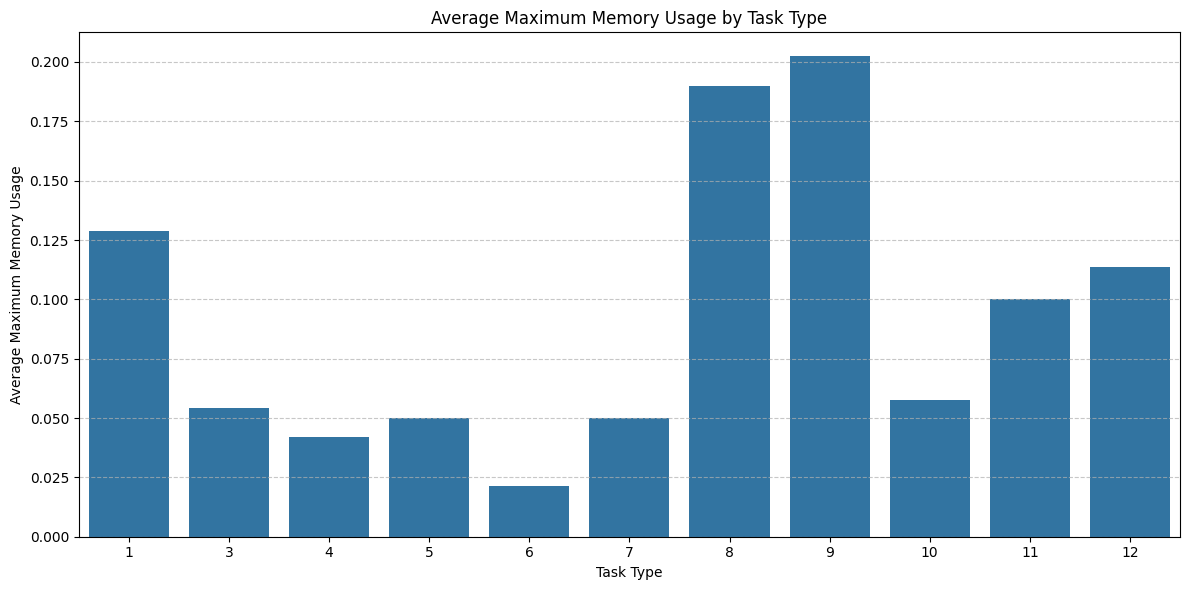

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(x=resource_usage_by_task_type.index, y='mem_max', data=resource_usage_by_task_type)
plt.title('Average Maximum Memory Usage by Task Type')
plt.xlabel('Task Type')
plt.ylabel('Average Maximum Memory Usage')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

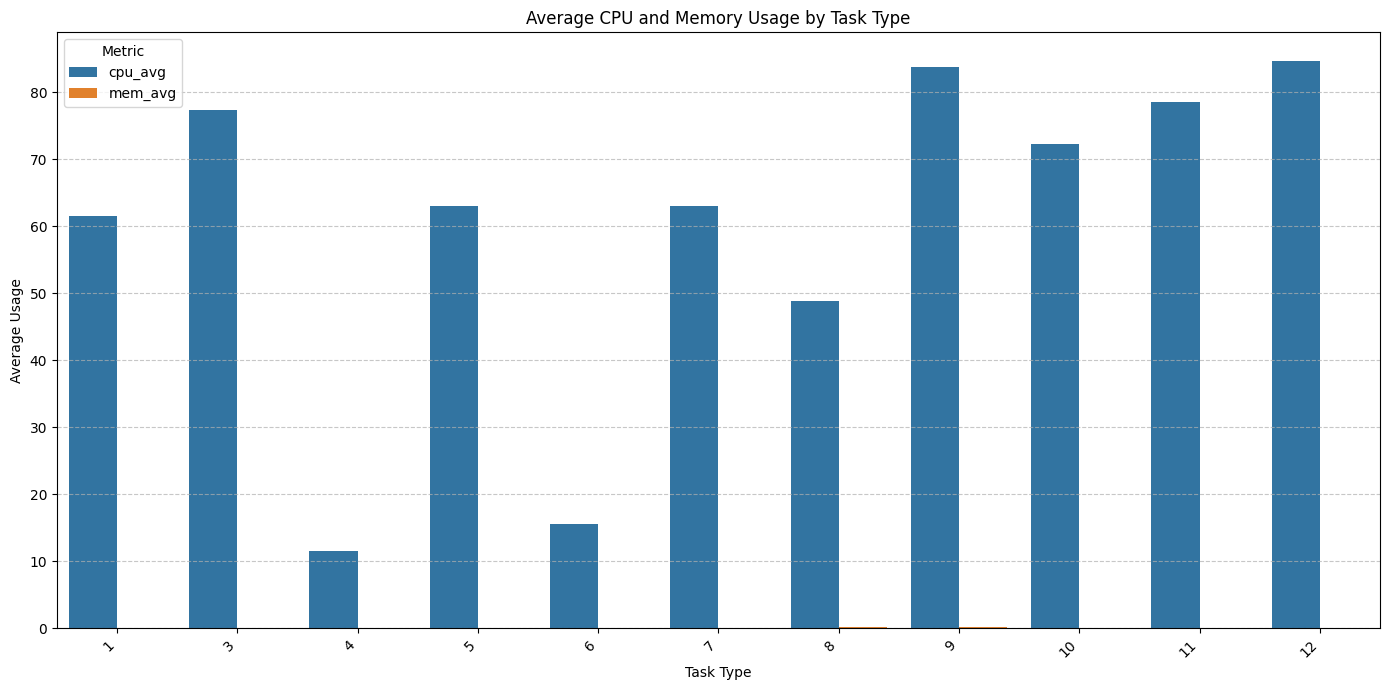

In [ ]:
resource_usage_melted = resource_usage_by_task_type[['cpu_avg', 'mem_avg']].reset_index().melt(id_vars='task_type', var_name='Metric', value_name='Average_Usage')

plt.figure(figsize=(14, 7))
sns.barplot(x='task_type', y='Average_Usage', hue='Metric', data=resource_usage_melted)
plt.title('Average CPU and Memory Usage by Task Type')
plt.xlabel('Task Type')
plt.ylabel('Average Usage')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

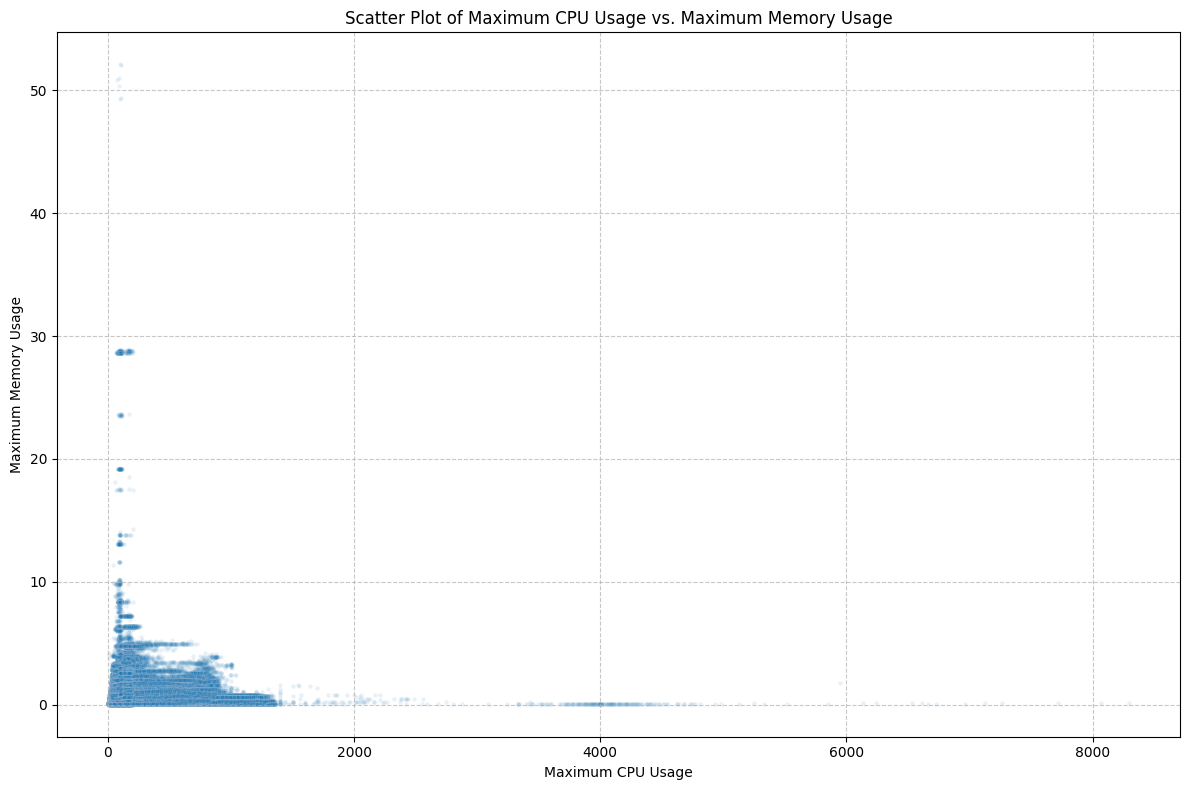

In [ ]:
plt.figure(figsize=(12, 8))
sns.scatterplot(x='cpu_max', y='mem_max', data=data, alpha=0.1, s=10)
plt.title('Scatter Plot of Maximum CPU Usage vs. Maximum Memory Usage')
plt.xlabel('Maximum CPU Usage')
plt.ylabel('Maximum Memory Usage')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
numerical_cols = data.select_dtypes(include=[np.number]).columns
correlation_matrix = data[numerical_cols].corr()
display(correlation_matrix)

,task_type,start_time,end_time,seq_no,total_seq_no,cpu_avg,cpu_max,mem_avg,mem_max
task_type,1.000000,0.045617,0.042359,0.037263,0.046312,-0.078513,-0.028025,-0.016350,-0.013537
start_time,0.045617,1.000000,0.996570,-0.008523,-0.011644,0.012967,-0.012529,-0.000610,-0.002642
end_time,0.042359,0.996570,1.000000,-0.011440,-0.024600,0.012805,-0.011718,0.000202,-0.001802
seq_no,0.037263,-0.008523,-0.011440,1.000000,0.657585,0.003784,0.012916,0.003523,0.002783
total_seq_no,0.046312,-0.011644,-0.024600,0.657585,1.000000,0.003085,0.005419,-0.000684,-0.001181
cpu_avg,-0.078513,0.012967,0.012805,0.003784,0.003085,1.000000,0.570972,0.040546,0.059961
cpu_max,-0.028025,-0.012529,-0.011718,0.012916,0.005419,0.570972,1.000000,0.206488,0.250768
mem_avg,-0.016350,-0.000610,0.000202,0.003523,-0.000684,0.040546,0.206488,1.000000,0.962972
mem_max,-0.013537,-0.002642,-0.001802,0.002783,-0.001181,0.059961,0.250768,0.962972,1.000000


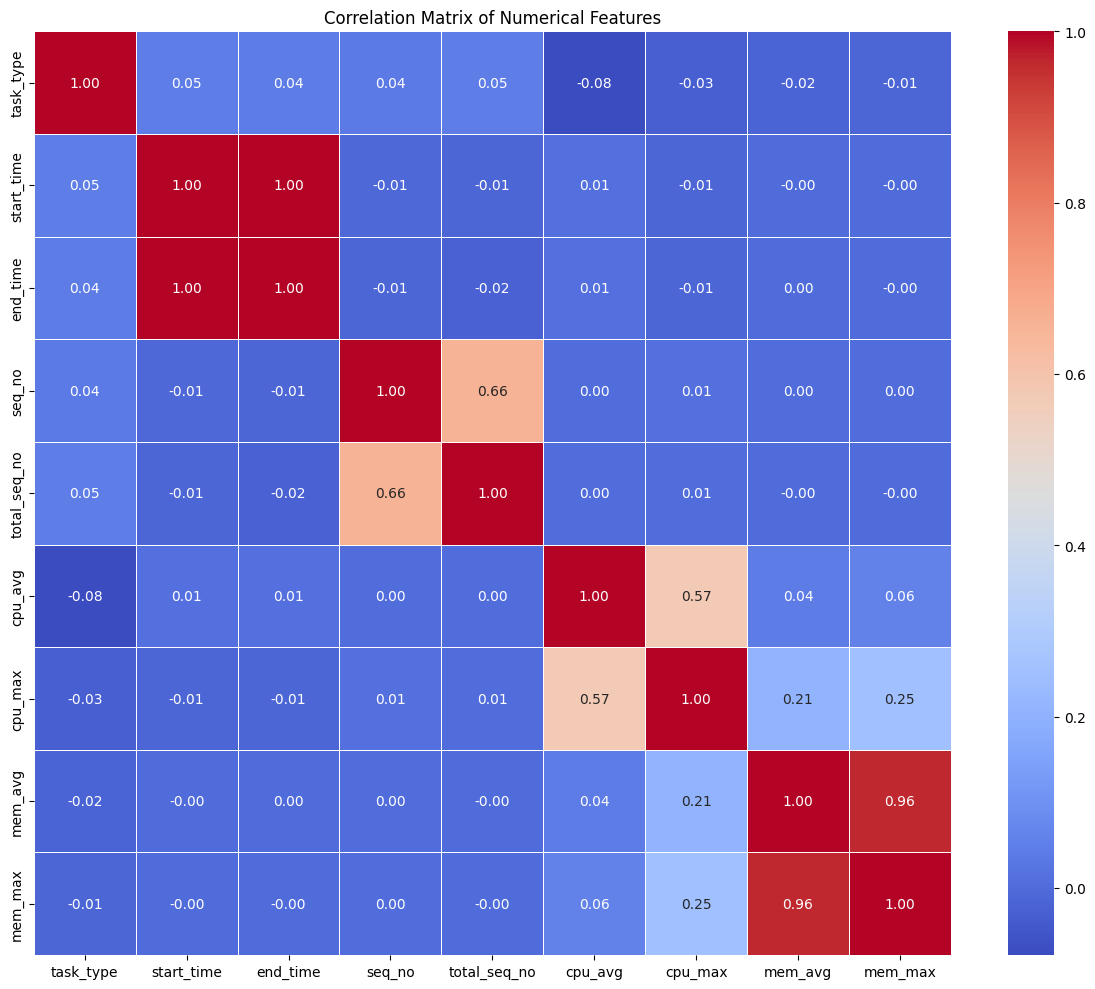

In [ ]:
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.show()

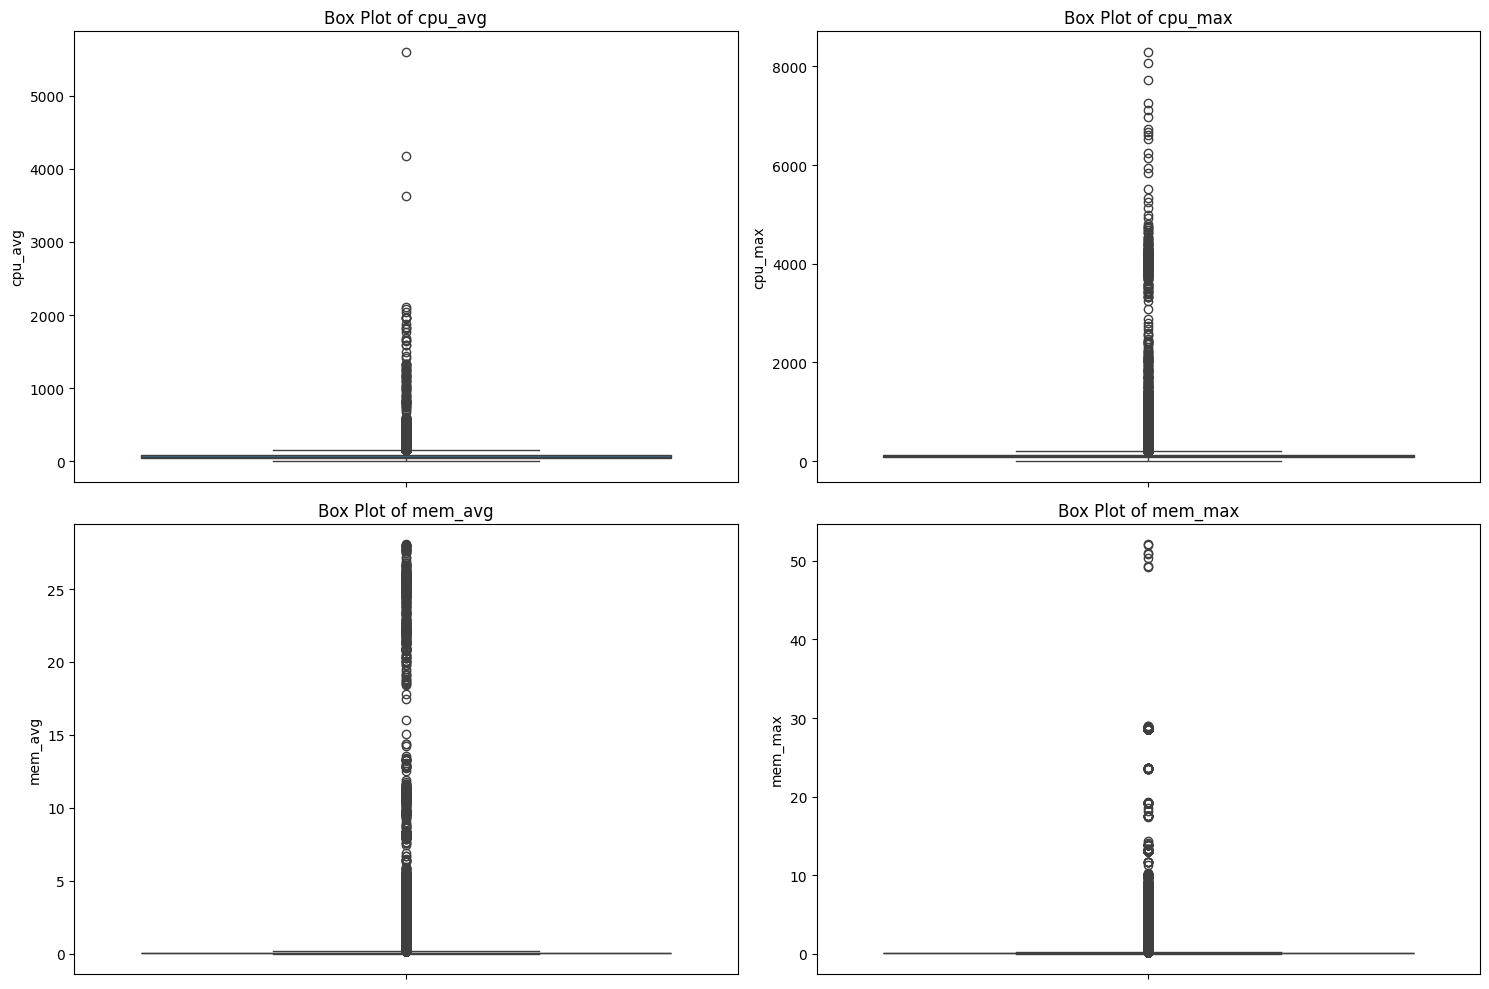

In [ ]:
resource_columns = ['cpu_avg', 'cpu_max', 'mem_avg', 'mem_max']

plt.figure(figsize=(15, 10))
for i, col in enumerate(resource_columns):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(y=data[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

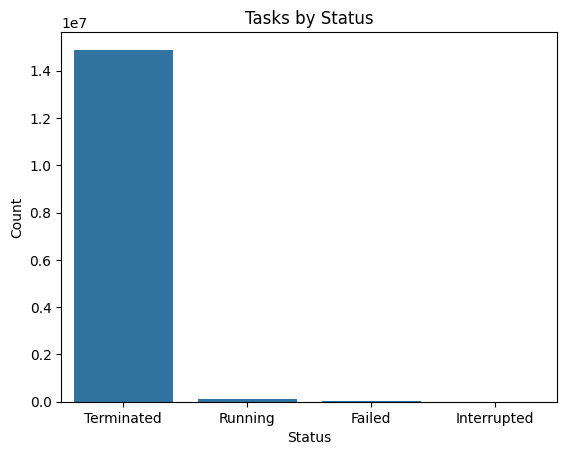

In [ ]:
sns.countplot(x='status', data=data)
plt.title('Tasks by Status')
plt.xlabel('Status')
plt.ylabel('Count')
plt.show()

In [10]:
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import class_weight

# Encode the 'status' column to numerical labels
le = LabelEncoder()
data['status_encoded'] = le.fit_transform(data['status'])

# --- New Strategy: Less aggressive downsampling and class weight calculation ---

# Define a target maximum number of samples per class.
# This allows using a larger subset than the original minority class count,
# while still managing highly imbalanced majority classes.
# Let's aim for a significantly larger sample, e.g., 50,000 per class, if available.
# Adjust this value based on available computational resources and dataset characteristics.
max_samples_per_class = 50000 # For example, up to 50,000 instances per class

# Get class counts
status_counts_full = data['status_encoded'].value_counts()

balanced_data_frames_less_aggressive = []

for status_label in status_counts_full.index:
    df_class = data[data['status_encoded'] == status_label]
    if len(df_class) > max_samples_per_class:
        # If a class is larger than max_samples_per_class, sample down to that size
        df_sampled = df_class.sample(n=max_samples_per_class, random_state=42)
        balanced_data_frames_less_aggressive.append(df_sampled)
    else:
        # Otherwise, take all instances of that class
        balanced_data_frames_less_aggressive.append(df_class)

# Concatenate the less aggressively balanced dataframes
data_balanced = pd.concat(balanced_data_frames_less_aggressive, axis=0).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Original dataset size: {data.shape[0]} rows")
print(f"Less aggressively balanced dataset size: {data_balanced.shape[0]} rows")
print("Class distribution in less aggressively balanced dataset:")
print(data_balanced['status_encoded'].value_counts())

# Optionally, you can also print the distribution of the original 'status' labels in the balanced dataset
print("\nOriginal 'status' distribution in less aggressively balanced dataset:")
print(data_balanced['status'].value_counts())

# Calculate class weights for the (possibly still imbalanced) data_balanced subset
# This helps the model learn from minority classes even if they are still outnumbered
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(data_balanced['status_encoded']),
    y=data_balanced['status_encoded']
)
class_weights_dict = {i: weight for i, weight in enumerate(class_weights)}
print(f"\nCalculated class weights: {class_weights_dict}")


# Define X and y for the less aggressively balanced dataset
X_balanced = data_balanced.drop(['instance_name', 'task_name', 'job_name', 'status', 'machine_id', 'status_encoded'], axis=1)
y_balanced = data_balanced['status_encoded']

print(f"\nX_balanced shape: {X_balanced.shape}")
print(f"y_balanced shape: {y_balanced.shape}")

Original dataset size: 15000000 rows
Less aggressively balanced dataset size: 112928 rows
Class distribution in less aggressively balanced dataset:
status_encoded
2    50000
3    50000
0    11471
1     1457
Name: count, dtype: int64

Original 'status' distribution in less aggressively balanced dataset:
status
Running        50000
Terminated     50000
Failed         11471
Interrupted     1457
Name: count, dtype: int64

Calculated class weights: {0: np.float64(2.4611629326126754), 1: np.float64(19.376801647220315), 2: np.float64(0.56464), 3: np.float64(0.56464)}

X_balanced shape: (112928, 9)
y_balanced shape: (112928,)


LSTM Model for Classification

Preprocessing data for LSTM...
X_train_lstm shape: (90342, 9, 1)
y_train_lstm shape: (90342, 4)
X_test_lstm shape: (22586, 9, 1)
y_test_lstm shape: (22586, 4)

Building LSTM model...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 9, 50)          │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 9, 50)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │           204 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,804 (120.33 KB)

 Trainable params: 30,804 (120.33 KB)

 Non-trainable params: 0 (0.00 B)

LSTM model built successfully!

Training LSTM model...
Epoch 1/20
2541/2541 ━━━━━━━━━━━━━━━━━━━━ 37s 12ms/step - accuracy: 0.7351 - loss: 0.5097 - val_accuracy: 0.8547 - val_loss: 0.4258
Epoch 2/20
2541/2541 ━━━━━━━━━━━━━━━━━━━━ 34s 11ms/step - accuracy: 0.8727 - loss: 0.2742 - val_accuracy: 0.8915 - val_loss: 0.2630
Epoch 3/20
2541/2541 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - accuracy: 0.8888 - loss: 0.2392 - val_accuracy: 0.8869 - val_loss: 0.2610
Epoch 4/20
2541/2541 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - accuracy: 0.9017 - loss: 0.2126 - val_accuracy: 0.9057 - val_loss: 0.1916
Epoch 5/20
2541/2541 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - accuracy: 0.9196 - loss: 0.1774 - val_accuracy: 0.9036 - val_loss: 0.1693
Epoch 6/20
2541/2541 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - accuracy: 0.9267 - loss: 0.1645 - val_accuracy: 0.9613 - val_loss: 0.1520
Epoch 7/20
2541/2541 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - accuracy: 0.9310 - loss: 0.1656 - val_accuracy: 0.9443 - val_loss: 0.1367
Epoch 8/20
2541/2541 ━━━━━

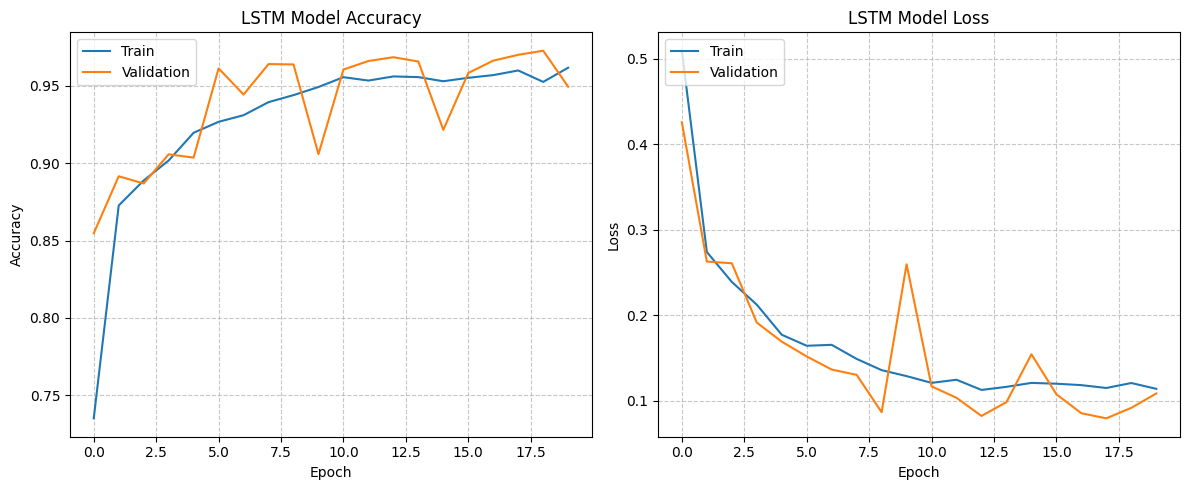


--- LSTM Model Performance ---
Test Accuracy: 0.9465
706/706 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.98      0.91      2294
           1       0.27      0.97      0.42       292
           2       0.99      0.89      0.94     10000
           3       1.00      1.00      1.00     10000

    accuracy                           0.95     22586
   macro avg       0.78      0.96      0.82     22586
weighted avg       0.97      0.95      0.96     22586



In [11]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input # Import Input layer
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
import numpy as np
import matplotlib.pyplot as plt # Ensure matplotlib is imported for plotting
import pandas as pd # Import pandas for DataFrame if model_performance needs it

print("LSTM Model for Classification\n")

print("Preprocessing data for LSTM...")

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_balanced)

# Reshape data for LSTM: (samples, timesteps, features)
# For tabular data, we're treating each feature as a timestep.
# So, (n_samples, n_features, 1) where each feature is a timestep.
X_reshaped = X_scaled.reshape(X_scaled.shape[0], X_scaled.shape[1], 1)

# One-hot encode the target variable
y_one_hot = to_categorical(y_balanced)

# Split the data into training and testing sets
X_train_lstm, X_test_lstm, y_train_lstm, y_test_lstm = train_test_split(
    X_reshaped, y_one_hot, test_size=0.2, random_state=42, stratify=y_balanced
)

print(f"X_train_lstm shape: {X_train_lstm.shape}")
print(f"y_train_lstm shape: {y_train_lstm.shape}")
print(f"X_test_lstm shape: {X_test_lstm.shape}")
print(f"y_test_lstm shape: {y_test_lstm.shape}")

print("\nBuilding LSTM model...")

# Define the LSTM model with Input layer to avoid the UserWarning
model = Sequential([
    Input(shape=(X_train_lstm.shape[1], 1)), # Recommended way to specify input shape
    LSTM(units=50, return_sequences=True),
    Dropout(0.2),
    LSTM(units=50, return_sequences=False),
    Dropout(0.2),
    Dense(units=y_train_lstm.shape[1], activation='softmax') # Output layer with softmax for multi-class
])

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()
print("LSTM model built successfully!")

print("\nTraining LSTM model...")

history = model.fit(
    X_train_lstm, y_train_lstm,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1,
    class_weight=class_weights_dict # Apply class weights here
)

print("LSTM model training complete!")

# Plot training history
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('LSTM Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('LSTM Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Evaluate the model on the test set
loss, accuracy = model.evaluate(X_test_lstm, y_test_lstm, verbose=0)
print(f"\n--- LSTM Model Performance ---")
print(f"Test Accuracy: {accuracy:.4f}")

y_pred_lstm_prob = model.predict(X_test_lstm)
y_pred_lstm = np.argmax(y_pred_lstm_prob, axis=1)
y_true_lstm = np.argmax(y_test_lstm, axis=1)

print("Classification Report:")
print(classification_report(y_true_lstm, y_pred_lstm))


In [ ]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score

# Assuming y_true_lstm and y_pred_lstm are available from previous execution
accuracy = accuracy_score(y_true_lstm, y_pred_lstm)
print(f"LSTM Model Accuracy: {accuracy:.4f}")
# precision
precision = precision_score(y_true_lstm, y_pred_lstm, average='weighted')
print(f"LSTM Model Precision: {precision:.4f}")
#recall
recall = recall_score(y_true_lstm, y_pred_lstm, average='weighted')
print(f"LSTM Model Recall: {recall:.4f}")
#f1_score
f1 = f1_score(y_true_lstm, y_pred_lstm, average='weighted')
print(f"LSTM Model F1 Score: {f1:.4f}")

# append all in a dict
model_performance ={}
model_performance['LSTM'] = {
    'accuracy': accuracy,
    'precision': precision,
    'recall': recall,
    'f1_score': f1
}


LSTM Model Accuracy: 0.9365
LSTM Model Precision: 0.9396
LSTM Model Recall: 0.9365
LSTM Model F1 Score: 0.9363


## Artificial Neural Network (ANN) Model for Classification

X_train_ann shape: (90342, 9)
y_train_ann shape: (90342, 4)
X_test_ann shape: (22586, 9)
y_test_ann shape: (22586, 4)

Building ANN model...


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 128)            │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,796 (38.27 KB)

 Trainable params: 9,796 (38.27 KB)

 Non-trainable params: 0 (0.00 B)

ANN model built successfully!

Training ANN model...
Epoch 1/20
2541/2541 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - accuracy: 0.8331 - loss: 0.4025 - val_accuracy: 0.8953 - val_loss: 0.2393
Epoch 2/20
2541/2541 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8921 - loss: 0.2407 - val_accuracy: 0.9100 - val_loss: 0.2065
Epoch 3/20
2541/2541 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9015 - loss: 0.2126 - val_accuracy: 0.8999 - val_loss: 0.1980
Epoch 4/20
2541/2541 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9066 - loss: 0.1975 - val_accuracy: 0.9069 - val_loss: 0.1494
Epoch 5/20
2541/2541 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9102 - loss: 0.1883 - val_accuracy: 0.9038 - val_loss: 0.1824
Epoch 6/20
2541/2541 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9126 - loss: 0.1824 - val_accuracy: 0.9138 - val_loss: 0.1608
Epoch 7/20
2541/2541 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9168 - loss: 0.1711 - val_accuracy: 0.9226 - val_loss: 0.1538
Epoch 8/20
2541/2541 ━━━━━━━━━━━━━━

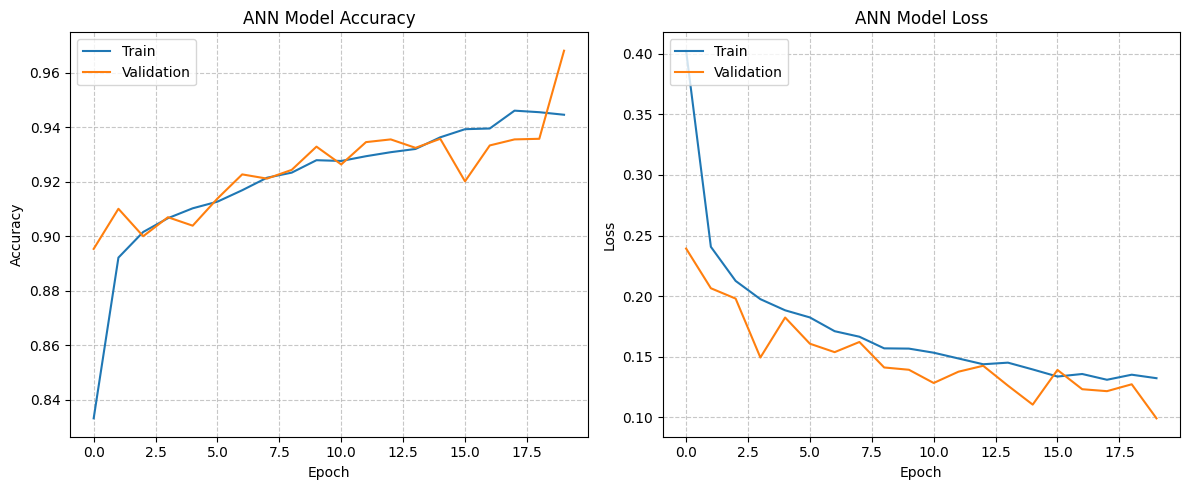


--- ANN Model Performance ---
Test Accuracy: 0.9664
706/706 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Classification Report for ANN:
              precision    recall  f1-score   support

           0       0.91      0.98      0.95      2294
           1       0.36      0.99      0.53       292
           2       1.00      0.93      0.96     10000
           3       1.00      1.00      1.00     10000

    accuracy                           0.97     22586
   macro avg       0.82      0.97      0.86     22586
weighted avg       0.98      0.97      0.97     22586


ANN Model Precision (weighted): 0.9812
ANN Model Recall (weighted): 0.9664
ANN Model F1 Score (weighted): 0.9713

Updated model_performance dictionary with ANN results:


,accuracy,precision,recall,f1_score
LSTM,0.936535,0.939602,0.936535,0.936325
ANN,0.966439,0.981210,0.966439,0.971338
GRU,0.953688,0.956531,0.953688,0.953207
hybrid(GRU-LSTM),0.950257,0.953311,0.950257,0.949749
hybrid(GRU-ANN),0.947684,0.951330,0.947684,0.947372


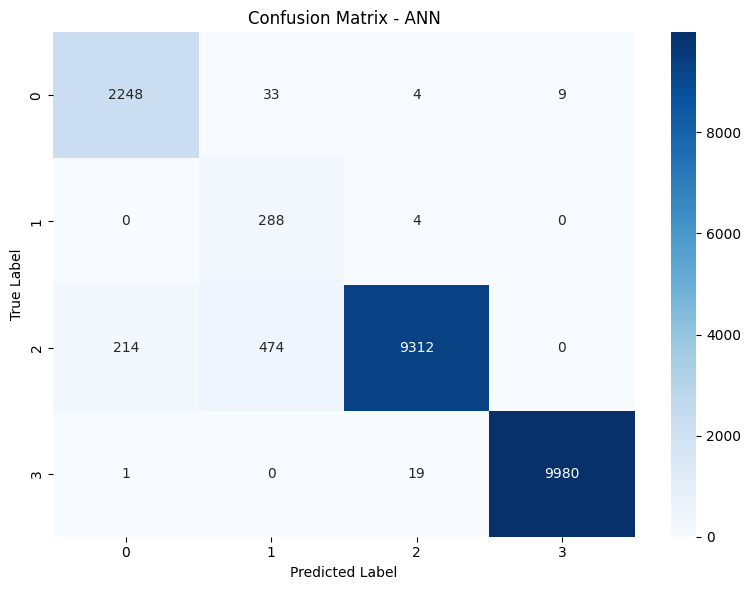

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

print("## Artificial Neural Network (ANN) Model for Classification\n")

# Reuse preprocessed and scaled data (X_scaled) and one-hot encoded labels (y_one_hot)
# For ANN, the input shape should be 2D (samples, features)

# Split data into training and testing sets
# Using X_scaled directly as it's already 2D (samples, features)
X_train_ann, X_test_ann, y_train_ann, y_test_ann = train_test_split(
    X_scaled, y_one_hot, test_size=0.2, random_state=42, stratify=np.argmax(y_one_hot, axis=1)
)

print(f"X_train_ann shape: {X_train_ann.shape}")
print(f"y_train_ann shape: {y_train_ann.shape}")
print(f"X_test_ann shape: {X_test_ann.shape}")
print(f"y_test_ann shape: {y_test_ann.shape}")

print("\nBuilding ANN model...")

# Define the ANN model
ann_model = Sequential([
    Input(shape=(X_train_ann.shape[1],)), # Input layer for 2D data
    Dense(units=128, activation='relu'),
    Dropout(0.3),
    Dense(units=64, activation='relu'),
    Dropout(0.3),
    Dense(units=y_train_ann.shape[1], activation='softmax') # Output layer with softmax for multi-class
])

# Compile the model
ann_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

ann_model.summary()
print("ANN model built successfully!")

print("\nTraining ANN model...")

history_ann = ann_model.fit(
    X_train_ann, y_train_ann,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1,
    class_weight=class_weights_dict # Apply class weights here
)

print("ANN model training complete!")

# Plot training history
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history_ann.history['accuracy'])
plt.plot(history_ann.history['val_accuracy'])
plt.title('ANN Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_ann.history['loss'])
plt.plot(history_ann.history['val_loss'])
plt.title('ANN Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Evaluate the model on the test set
loss_ann, accuracy_ann = ann_model.evaluate(X_test_ann, y_test_ann, verbose=0)
print(f"\n--- ANN Model Performance ---")
print(f"Test Accuracy: {accuracy_ann:.4f}")

y_pred_ann_prob = ann_model.predict(X_test_ann)
y_pred_ann = np.argmax(y_pred_ann_prob, axis=1)
y_true_ann = np.argmax(y_test_ann, axis=1)

print("Classification Report for ANN:")
print(classification_report(y_true_ann, y_pred_ann))

# Calculate individual metrics
precision_ann = precision_score(y_true_ann, y_pred_ann, average='weighted')
recall_ann = recall_score(y_true_ann, y_pred_ann, average='weighted')
f1_ann = f1_score(y_true_ann, y_pred_ann, average='weighted')

print(f"\nANN Model Precision (weighted): {precision_ann:.4f}")
print(f"ANN Model Recall (weighted): {recall_ann:.4f}")
print(f"ANN Model F1 Score (weighted): {f1_ann:.4f}")

# Add ANN performance to model_performance dictionary
# Ensure model_performance is a dictionary or DataFrame from previous steps
if 'model_performance' not in locals() or not isinstance(model_performance, (dict, pd.DataFrame)):
    model_performance = {}

# If model_performance is a DataFrame, convert it to dict, update, then convert back
if isinstance(model_performance, pd.DataFrame):
    model_performance_dict = model_performance.to_dict()
else:
    model_performance_dict = model_performance

model_performance_dict['ANN'] = {
    'accuracy': accuracy_ann,
    'precision': precision_ann,
    'recall': recall_ann,
    'f1_score': f1_ann
}

model_performance = pd.DataFrame(model_performance_dict) # Convert back to DataFrame

print("\nUpdated model_performance dictionary with ANN results:")
display(model_performance.T)

# Plot Confusion Matrix for ANN
# Get unique class labels from y_balanced (or directly from the LabelEncoder if available)
# Assuming y_balanced contains integer labels 0, 1, 2, 3
class_labels = [str(label) for label in sorted(np.unique(y_balanced))]

plt.figure(figsize=(8, 6))
cm_ann = confusion_matrix(y_true_ann, y_pred_ann)
sns.heatmap(cm_ann, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title(f'Confusion Matrix - ANN')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

GRU Model for Classification

Reusing preprocessed data shapes for GRU:
X_train_lstm shape: (90342, 9, 1)
y_train_lstm shape: (90342, 4)
X_test_lstm shape: (22586, 9, 1)
y_test_lstm shape: (22586, 4)

Building GRU model...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_4 (GRU)                     │ (None, 9, 50)          │         7,950 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 9, 50)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_5 (GRU)                     │ (None, 50)             │        15,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 4)              │           204 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,454 (91.62 KB)

 Trainable params: 23,454 (91.62 KB)

 Non-trainable params: 0 (0.00 B)

GRU model built successfully!

Training GRU model...
Epoch 1/20
2541/2541 ━━━━━━━━━━━━━━━━━━━━ 26s 9ms/step - accuracy: 0.7951 - loss: 0.4110 - val_accuracy: 0.8688 - val_loss: 0.4039
Epoch 2/20
2541/2541 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - accuracy: 0.8912 - loss: 0.2325 - val_accuracy: 0.8849 - val_loss: 0.2779
Epoch 3/20
2541/2541 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - accuracy: 0.9042 - loss: 0.2007 - val_accuracy: 0.9102 - val_loss: 0.1619
Epoch 4/20
2541/2541 ━━━━━━━━━━━━━━━━━━━━ 27s 10ms/step - accuracy: 0.9165 - loss: 0.1815 - val_accuracy: 0.9078 - val_loss: 0.1737
Epoch 5/20
2541/2541 ━━━━━━━━━━━━━━━━━━━━ 38s 9ms/step - accuracy: 0.9235 - loss: 0.1677 - val_accuracy: 0.9085 - val_loss: 0.1903
Epoch 6/20
2541/2541 ━━━━━━━━━━━━━━━━━━━━ 40s 9ms/step - accuracy: 0.9305 - loss: 0.1594 - val_accuracy: 0.9590 - val_loss: 0.1339
Epoch 7/20
2541/2541 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - accuracy: 0.9351 - loss: 0.1525 - val_accuracy: 0.9471 - val_loss: 0.1517
Epoch 8/20
2541/2541 ━━━━━━━━

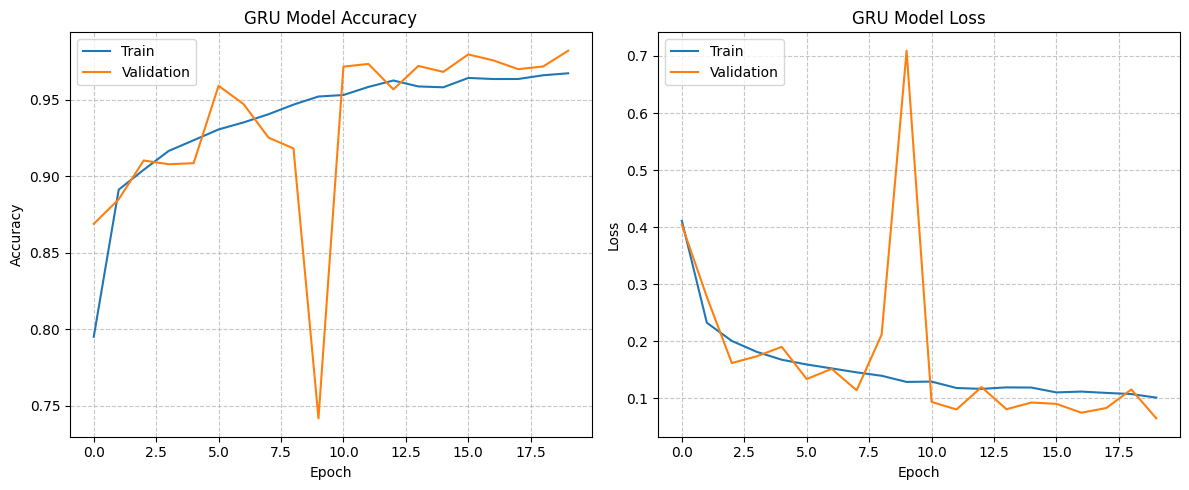


--- GRU Model Performance ---
Test Accuracy: 0.9817
706/706 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step
Classification Report for GRU:
              precision    recall  f1-score   support

           0       0.93      0.98      0.95      2294
           1       0.61      0.98      0.75       292
           2       0.99      0.97      0.98     10000
           3       1.00      0.99      1.00     10000

    accuracy                           0.98     22586
   macro avg       0.88      0.98      0.92     22586
weighted avg       0.99      0.98      0.98     22586


GRU Model Precision (weighted): 0.9850
GRU Model Recall (weighted): 0.9817
GRU Model F1 Score (weighted): 0.9827


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
import numpy as np

print("GRU Model for Classification\n")

# Data (X_reshaped, y_one_hot, X_train_lstm, X_test_lstm, y_train_lstm, y_test_lstm)
# is already prepared from the LSTM step and can be reused.
print(f"Reusing preprocessed data shapes for GRU:")
print(f"X_train_lstm shape: {X_train_lstm.shape}")
print(f"y_train_lstm shape: {y_train_lstm.shape}")
print(f"X_test_lstm shape: {X_test_lstm.shape}")
print(f"y_test_lstm shape: {y_test_lstm.shape}")

print("\nBuilding GRU model...")

# Define the GRU model, mirroring the LSTM architecture
gru_model = Sequential([
    GRU(units=50, return_sequences=True, input_shape=(X_train_lstm.shape[1], 1)),
    Dropout(0.2),
    GRU(units=50, return_sequences=False),
    Dropout(0.2),
    Dense(units=y_train_lstm.shape[1], activation='softmax') # Output layer with softmax for multi-class
])

# Compile the model
gru_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

gru_model.summary()
print("GRU model built successfully!")

print("\nTraining GRU model...")

history_gru = gru_model.fit(
    X_train_lstm, y_train_lstm,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1,
    class_weight=class_weights_dict # Apply class weights here
)

print("GRU model training complete!")

# Plot training history
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history_gru.history['accuracy'])
plt.plot(history_gru.history['val_accuracy'])
plt.title('GRU Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_gru.history['loss'])
plt.plot(history_gru.history['val_loss'])
plt.title('GRU Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Evaluate the model on the test set
loss_gru, accuracy_gru = gru_model.evaluate(X_test_lstm, y_test_lstm, verbose=0)
print(f"\n--- GRU Model Performance ---")
print(f"Test Accuracy: {accuracy_gru:.4f}")

y_pred_gru_prob = gru_model.predict(X_test_lstm)
y_pred_gru = np.argmax(y_pred_gru_prob, axis=1)
y_true_gru = np.argmax(y_test_lstm, axis=1)

print("Classification Report for GRU:")
print(classification_report(y_true_gru, y_pred_gru))

# Calculate individual metrics
precision_gru = precision_score(y_true_gru, y_pred_gru, average='weighted')
recall_gru = recall_score(y_true_gru, y_pred_gru, average='weighted')
f1_gru = f1_score(y_true_gru, y_pred_gru, average='weighted')

print(f"\nGRU Model Precision (weighted): {precision_gru:.4f}")
print(f"GRU Model Recall (weighted): {recall_gru:.4f}")
print(f"GRU Model F1 Score (weighted): {f1_gru:.4f}")


In [ ]:
model_performance['GRU'] = {
    'accuracy': accuracy_gru,
    'precision': precision_gru,
    'recall': recall_gru,
    'f1_score': f1_gru
}

print("Updated model_performance dictionary with GRU results:")
print(model_performance)

Updated model_performance dictionary with GRU results:
               LSTM       ANN       GRU
accuracy   0.936535  0.949400  0.953688
precision  0.939602  0.951318  0.956531
recall     0.936535  0.949400  0.953688
f1_score   0.936325  0.948934  0.953207


## Hybrid GRU-LSTM Model for Classification

Reusing preprocessed data shapes for Hybrid GRU-LSTM:
X_train_lstm shape: (90342, 9, 1)
y_train_lstm shape: (90342, 4)
X_test_lstm shape: (22586, 9, 1)
y_test_lstm shape: (22586, 4)

Building Hybrid GRU-LSTM model...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_6 (GRU)                     │ (None, 9, 64)          │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 9, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,148 (180.27 KB)

 Trainable params: 46,148 (180.27 KB)

 Non-trainable params: 0 (0.00 B)

Hybrid GRU-LSTM model built successfully!

Training Hybrid GRU-LSTM model...
Epoch 1/20
2541/2541 ━━━━━━━━━━━━━━━━━━━━ 27s 10ms/step - accuracy: 0.7888 - loss: 0.4126 - val_accuracy: 0.8918 - val_loss: 0.2095
Epoch 2/20
2541/2541 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - accuracy: 0.8944 - loss: 0.2243 - val_accuracy: 0.9050 - val_loss: 0.1834
Epoch 3/20
2541/2541 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - accuracy: 0.9091 - loss: 0.1975 - val_accuracy: 0.8950 - val_loss: 0.2709
Epoch 4/20
2541/2541 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - accuracy: 0.9217 - loss: 0.1734 - val_accuracy: 0.9180 - val_loss: 0.1607
Epoch 5/20
2541/2541 ━━━━━━━━━━━━━━━━━━━━ 24s 10ms/step - accuracy: 0.9324 - loss: 0.1553 - val_accuracy: 0.9665 - val_loss: 0.1318
Epoch 6/20
2541/2541 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - accuracy: 0.9413 - loss: 0.1510 - val_accuracy: 0.9685 - val_loss: 0.1186
Epoch 7/20
2541/2541 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - accuracy: 0.9496 - loss: 0.1359 - val_accuracy: 0.9103 - val_loss: 0.2487
Epoc

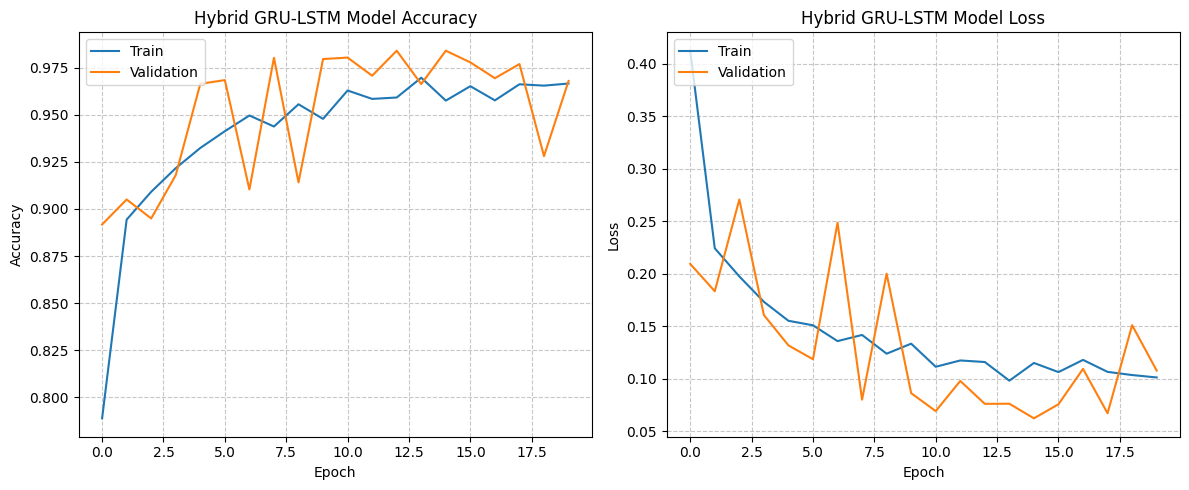


--- Hybrid GRU-LSTM Model Performance ---
Test Accuracy: 0.9661


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
import numpy as np

print("## Hybrid GRU-LSTM Model for Classification\n")

# Reusing preprocessed data from LSTM/GRU steps
# X_train_lstm, X_test_lstm, y_train_lstm, y_test_lstm are already available
print(f"Reusing preprocessed data shapes for Hybrid GRU-LSTM:")
print(f"X_train_lstm shape: {X_train_lstm.shape}")
print(f"y_train_lstm shape: {y_train_lstm.shape}")
print(f"X_test_lstm shape: {X_test_lstm.shape}")
print(f"y_test_lstm shape: {y_test_lstm.shape}")

print("\nBuilding Hybrid GRU-LSTM model...")

# Define the Hybrid GRU-LSTM model
hybrid_model = Sequential([
    GRU(units=64, return_sequences=True, input_shape=(X_train_lstm.shape[1], 1)),
    Dropout(0.2),
    LSTM(units=64, return_sequences=False),
    Dropout(0.2),
    Dense(units=y_train_lstm.shape[1], activation='softmax') # Output layer with softmax for multi-class
])

# Compile the model
hybrid_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

hybrid_model.summary()
print("Hybrid GRU-LSTM model built successfully!")

print("\nTraining Hybrid GRU-LSTM model...")

history_hybrid = hybrid_model.fit(
    X_train_lstm, y_train_lstm,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1,
    class_weight=class_weights_dict # Apply class weights here
)

print("Hybrid GRU-LSTM model training complete!")

# Plot training history
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history_hybrid.history['accuracy'])
plt.plot(history_hybrid.history['val_accuracy'])
plt.title('Hybrid GRU-LSTM Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_hybrid.history['loss'])
plt.plot(history_hybrid.history['val_loss'])
plt.title('Hybrid GRU-LSTM Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Evaluate the model on the test set
loss_hybrid, accuracy_hybrid = hybrid_model.evaluate(X_test_lstm, y_test_lstm, verbose=0)
print(f"\n--- Hybrid GRU-LSTM Model Performance ---")
print(f"Test Accuracy: {accuracy_hybrid:.4f}")


In [ ]:
y_pred_hybrid = np.argmax(hybrid_model.predict(X_test_lstm), axis=1)
y_true_hybrid = np.argmax(y_test_lstm, axis=1)

precision_hybrid = precision_score(y_true_hybrid, y_pred_hybrid, average='weighted')
recall_hybrid = recall_score(y_true_hybrid, y_pred_hybrid, average='weighted')
f1_hybrid = f1_score(y_true_hybrid, y_pred_hybrid, average='weighted')

model_performance['hybrid(GRU-LSTM)'] = {
    'accuracy': accuracy_hybrid,
    'precision': precision_hybrid,
    'recall': recall_hybrid,
    'f1_score': f1_hybrid
}


37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


In [ ]:
model_performance=pd.DataFrame(model_performance)
model_performance.T

,accuracy,precision,recall,f1_score
LSTM,0.936535,0.939602,0.936535,0.936325
ANN,0.949400,0.951318,0.949400,0.948934
GRU,0.953688,0.956531,0.953688,0.953207
hybrid(GRU-LSTM),0.950257,0.953311,0.950257,0.949749


## Hybrid GRU-ANN Model for Classification

Reusing preprocessed data shapes for Hybrid GRU-ANN:
X_train_lstm shape: (90342, 9, 1)
y_train_lstm shape: (90342, 4)
X_test_lstm shape: (22586, 9, 1)
y_test_lstm shape: (22586, 4)

Building Hybrid GRU-ANN model...


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_7 (GRU)                     │ (None, 64)             │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,284 (67.52 KB)

 Trainable params: 17,284 (67.52 KB)

 Non-trainable params: 0 (0.00 B)

Hybrid GRU-ANN model built successfully!

Training Hybrid GRU-ANN model...
Epoch 1/20
2541/2541 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - accuracy: 0.7627 - loss: 0.4869 - val_accuracy: 0.8564 - val_loss: 0.3384
Epoch 2/20
2541/2541 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - accuracy: 0.8721 - loss: 0.2750 - val_accuracy: 0.8860 - val_loss: 0.2676
Epoch 3/20
2541/2541 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - accuracy: 0.8965 - loss: 0.2250 - val_accuracy: 0.9063 - val_loss: 0.1947
Epoch 4/20
2541/2541 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - accuracy: 0.9136 - loss: 0.1825 - val_accuracy: 0.9716 - val_loss: 0.1280
Epoch 5/20
2541/2541 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - accuracy: 0.9304 - loss: 0.1652 - val_accuracy: 0.9586 - val_loss: 0.1607
Epoch 6/20
2541/2541 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - accuracy: 0.9254 - loss: 0.1661 - val_accuracy: 0.9143 - val_loss: 0.1391
Epoch 7/20
2541/2541 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - accuracy: 0.9453 - loss: 0.1463 - val_accuracy: 0.9595 - val_loss: 0.1229
Epoch 8/

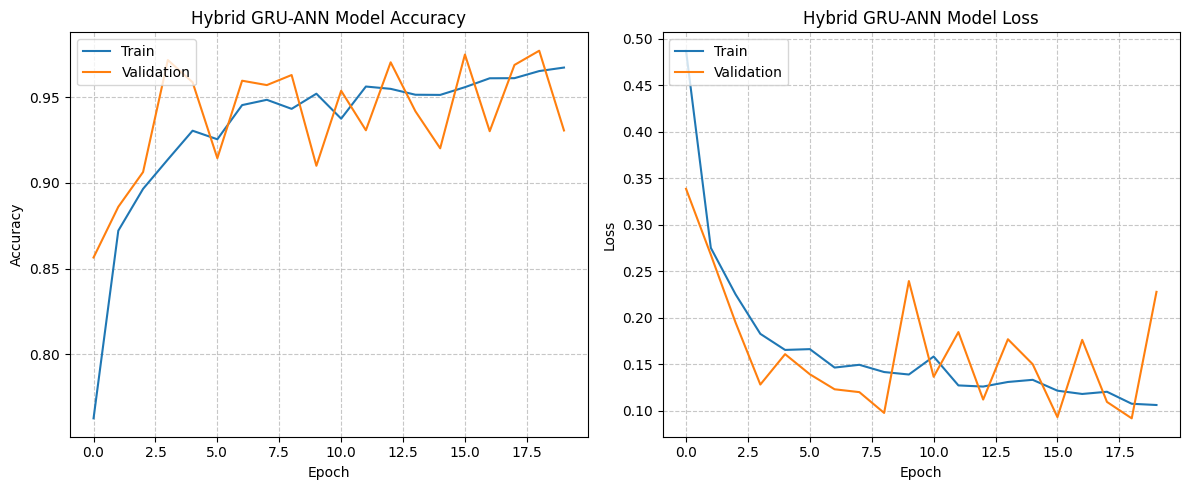


--- Hybrid GRU-ANN Model Performance ---
Test Accuracy: 0.9273
706/706 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
Classification Report for Hybrid GRU-ANN:
              precision    recall  f1-score   support

           0       0.91      0.98      0.94      2294
           1       0.17      0.99      0.30       292
           2       1.00      0.85      0.92     10000
           3       1.00      0.99      1.00     10000

    accuracy                           0.93     22586
   macro avg       0.77      0.95      0.79     22586
weighted avg       0.98      0.93      0.95     22586


Hybrid GRU-ANN Model Precision (weighted): 0.9774
Hybrid GRU-ANN Model Recall (weighted): 0.9273
Hybrid GRU-ANN Model F1 Score (weighted): 0.9459

Updated model_performance with Hybrid GRU-ANN results:


,accuracy,precision,recall,f1_score
LSTM,0.936535,0.939602,0.936535,0.936325
ANN,0.966439,0.981210,0.966439,0.971338
GRU,0.953688,0.956531,0.953688,0.953207
hybrid(GRU-LSTM),0.950257,0.953311,0.950257,0.949749
hybrid(GRU-ANN),0.927256,0.977400,0.927256,0.945939


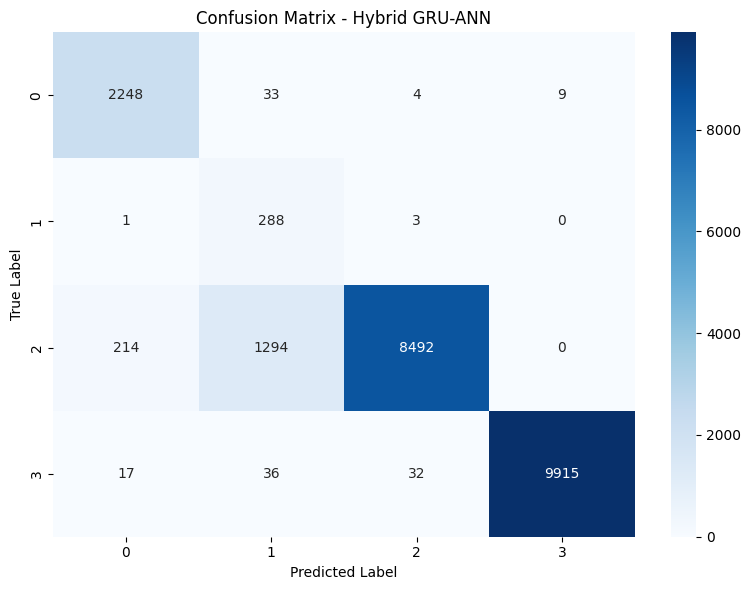

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout, Flatten, Input # Import Input layer
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

print("## Hybrid GRU-ANN Model for Classification\n")

# Reusing preprocessed data from previous steps
# X_train_lstm, X_test_lstm, y_train_lstm, y_test_lstm are already available
print(f"Reusing preprocessed data shapes for Hybrid GRU-ANN:")
print(f"X_train_lstm shape: {X_train_lstm.shape}")
print(f"y_train_lstm shape: {y_train_lstm.shape}")
print(f"X_test_lstm shape: {X_test_lstm.shape}")
print(f"y_test_lstm shape: {y_test_lstm.shape}")

print("\nBuilding Hybrid GRU-ANN model...")

# Define the Hybrid GRU-ANN model
hybrid_gru_ann_model = Sequential([
    Input(shape=(X_train_lstm.shape[1], 1)), # GRU layer expects 3D input
    GRU(units=64, return_sequences=False), # return_sequences=False outputs 2D tensor
    Dropout(0.2),
    # No need for Flatten if GRU's return_sequences=False
    Dense(units=64, activation='relu'),
    Dropout(0.2),
    Dense(units=y_train_lstm.shape[1], activation='softmax') # Output layer with softmax for multi-class
])

# Compile the model
hybrid_gru_ann_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

hybrid_gru_ann_model.summary()
print("Hybrid GRU-ANN model built successfully!")

print("\nTraining Hybrid GRU-ANN model...")

history_hybrid_gru_ann = hybrid_gru_ann_model.fit(
    X_train_lstm, y_train_lstm,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1,
    class_weight=class_weights_dict # Apply class weights here
)

print("Hybrid GRU-ANN model training complete!")

# Plot training history
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history_hybrid_gru_ann.history['accuracy'])
plt.plot(history_hybrid_gru_ann.history['val_accuracy'])
plt.title('Hybrid GRU-ANN Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_hybrid_gru_ann.history['loss'])
plt.plot(history_hybrid_gru_ann.history['val_loss'])
plt.title('Hybrid GRU-ANN Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Evaluate the model on the test set
loss_hybrid_gru_ann, accuracy_hybrid_gru_ann = hybrid_gru_ann_model.evaluate(X_test_lstm, y_test_lstm, verbose=0)
print(f"\n--- Hybrid GRU-ANN Model Performance ---")
print(f"Test Accuracy: {accuracy_hybrid_gru_ann:.4f}")

y_pred_hybrid_gru_ann_prob = hybrid_gru_ann_model.predict(X_test_lstm)
y_pred_hybrid_gru_ann = np.argmax(y_pred_hybrid_gru_ann_prob, axis=1)
y_true_hybrid_gru_ann = np.argmax(y_test_lstm, axis=1)

print("Classification Report for Hybrid GRU-ANN:")
print(classification_report(y_true_hybrid_gru_ann, y_pred_hybrid_gru_ann))

# Calculate individual metrics
precision_hybrid_gru_ann = precision_score(y_true_hybrid_gru_ann, y_pred_hybrid_gru_ann, average='weighted')
recall_hybrid_gru_ann = recall_score(y_true_hybrid_gru_ann, y_pred_hybrid_gru_ann, average='weighted')
f1_hybrid_gru_ann = f1_score(y_true_hybrid_gru_ann, y_pred_hybrid_gru_ann, average='weighted')

print(f"\nHybrid GRU-ANN Model Precision (weighted): {precision_hybrid_gru_ann:.4f}")
print(f"Hybrid GRU-ANN Model Recall (weighted): {recall_hybrid_gru_ann:.4f}")
print(f"Hybrid GRU-ANN Model F1 Score (weighted): {f1_hybrid_gru_ann:.4f}")

# Add Hybrid GRU-ANN performance to model_performance dictionary/DataFrame
# Ensure model_performance is a dictionary or DataFrame from previous steps
if 'model_performance' not in locals() or not isinstance(model_performance, (dict, pd.DataFrame)):
    model_performance = {}

# If model_performance is a DataFrame, convert it to dict, update, then convert back
if isinstance(model_performance, pd.DataFrame):
    model_performance_dict = model_performance.to_dict()
else:
    model_performance_dict = model_performance

model_performance_dict['hybrid(GRU-ANN)'] = {
    'accuracy': accuracy_hybrid_gru_ann,
    'precision': precision_hybrid_gru_ann,
    'recall': recall_hybrid_gru_ann,
    'f1_score': f1_hybrid_gru_ann
}

model_performance = pd.DataFrame(model_performance_dict) # Convert back to DataFrame

print("\nUpdated model_performance with Hybrid GRU-ANN results:")
display(model_performance.T)

# Plot Confusion Matrix for Hybrid GRU-ANN
# Get unique class labels from y_balanced (or directly from the LabelEncoder if available)
# Assuming y_balanced contains integer labels 0, 1, 2, 3
class_labels = [str(label) for label in sorted(np.unique(y_balanced))]

plt.figure(figsize=(8, 6))
cm_hybrid_gru_ann = confusion_matrix(y_true_hybrid_gru_ann, y_pred_hybrid_gru_ann)
sns.heatmap(cm_hybrid_gru_ann, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title(f'Confusion Matrix - Hybrid GRU-ANN')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

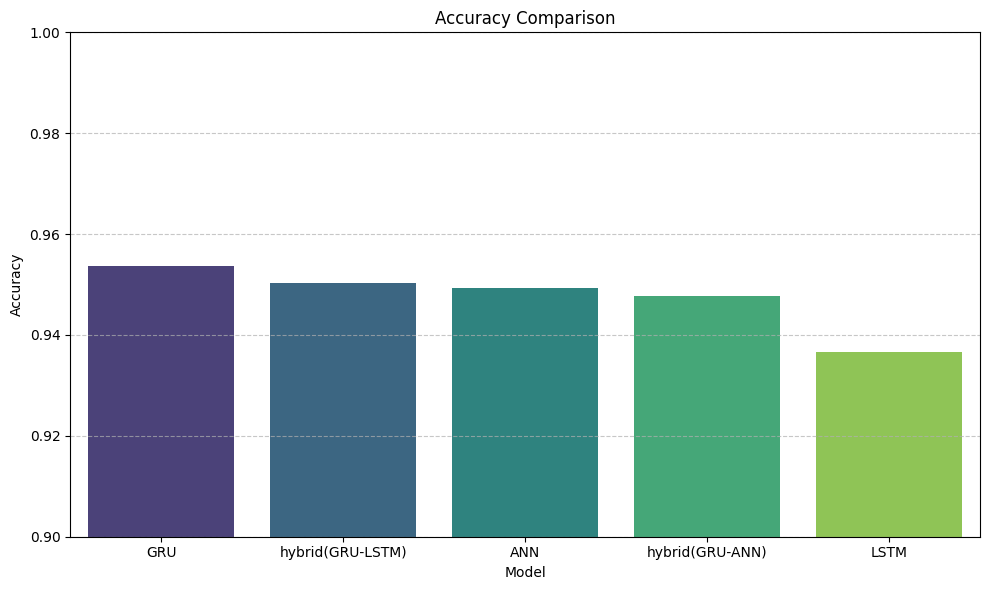

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extract accuracy for the three deep learning models from the model_performance DataFrame
# The model_performance DataFrame is already transposed and contains 'accuracy' as a row
dl_models_accuracy = model_performance.loc['accuracy', ['LSTM','ANN', 'GRU', 'hybrid(GRU-LSTM)', 'hybrid(GRU-ANN)']].reset_index()
dl_models_accuracy.columns = ['Model', 'Accuracy']

# Sort by accuracy for better visualization
dl_models_accuracy = dl_models_accuracy.sort_values(by='Accuracy', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Accuracy', data=dl_models_accuracy, palette='viridis', hue='Model', legend=False)
plt.title('Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0.9, 1.0) # Set y-axis limit to focus on the performance range
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

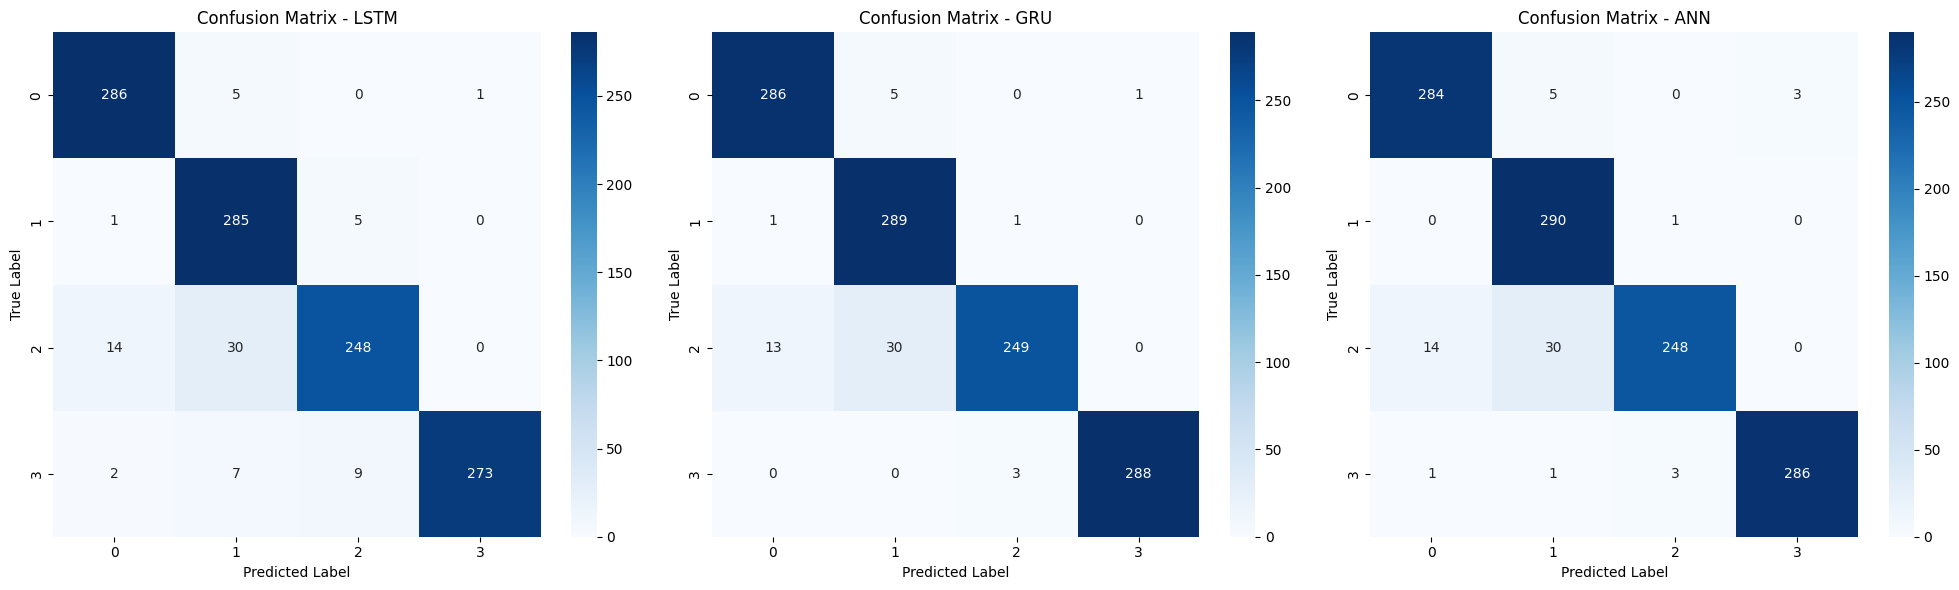

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_confusion_matrix(y_true, y_pred, model_name, class_labels, ax):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=class_labels, yticklabels=class_labels)
    ax.set_title(f'Confusion Matrix - {model_name}')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

# Get unique class labels from y_balanced (or directly from the LabelEncoder if available)
# Assuming y_balanced contains integer labels 0, 1, 2, 3
class_labels = [str(label) for label in sorted(np.unique(y_balanced))]

# Create a figure with subplots for each confusion matrix
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# LSTM Confusion Matrix
plot_confusion_matrix(y_true_lstm, y_pred_lstm, 'LSTM', class_labels, axes[0])

# GRU Confusion Matrix
plot_confusion_matrix(y_true_gru, y_pred_gru, 'GRU', class_labels, axes[1])

# ANN Confusion Matrix
plot_confusion_matrix(y_true_ann, y_pred_hybrid, 'ANN', class_labels, axes[2])

plt.tight_layout()
plt.show()

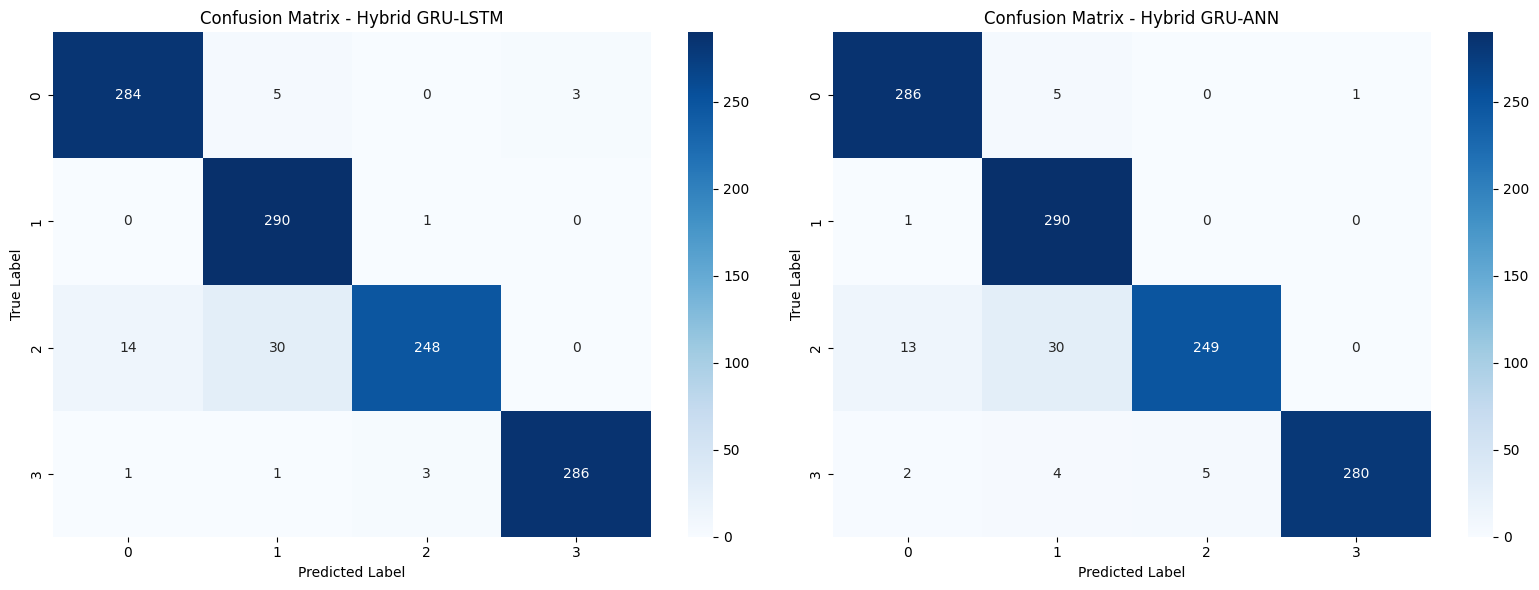

In [ ]:
# Create a figure with subplots for each hybrid confusion matrix
fig_hybrid, axes_hybrid = plt.subplots(1, 2, figsize=(16, 6))

# Hybrid GRU-LSTM Confusion Matrix
plot_confusion_matrix(y_true_hybrid, y_pred_hybrid, 'Hybrid GRU-LSTM', class_labels, axes_hybrid[0])

# Hybrid GRU-ANN Confusion Matrix
plot_confusion_matrix(y_true_hybrid_gru_ann, y_pred_hybrid_gru_ann, 'Hybrid GRU-ANN', class_labels, axes_hybrid[1])

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

def plot_roc_curve(y_true_one_hot, y_pred_prob, model_name, class_labels, n_classes, ax):
    # Compute micro-average ROC curve and ROC area
    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    # Compute ROC curve and ROC area for each class
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_one_hot[:, i], y_pred_prob[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Aggregate all false positive rates
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))

    # Interpolate all ROC curves at these points
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

    # Average and compute AUC
    mean_tpr /= n_classes

    fpr["macro"] = all_fpr
    tpr["macro"] = mean_tpr
    roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

    # Plot all ROC curves
    ax.plot(fpr["macro"], tpr["macro"],
            label=f'macro-average ROC (area = {roc_auc["macro"]:.2f})',
            color='navy', linestyle=':', linewidth=4)

    colors = plt.cm.get_cmap('jet', n_classes)(np.linspace(0, 1, n_classes))
    for i, color in zip(range(n_classes), colors):
        ax.plot(fpr[i], tpr[i], color=color, lw=2,
                label=f'ROC curve of class {class_labels[i]} (area = {roc_auc[i]:.2f})')

    ax.plot([0, 1], [0, 1], 'k--', lw=2)
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'Receiver Operating Characteristic - {model_name}')
    ax.legend(loc="lower right")
    ax.grid(True, linestyle='--', alpha=0.7)
    return roc_auc["macro"]

print("ROC curve plotting function defined.")

ROC curve plotting function defined.


/tmp/ipykernel_14960/4218240784.py:35: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('jet', n_classes)(np.linspace(0, 1, n_classes))


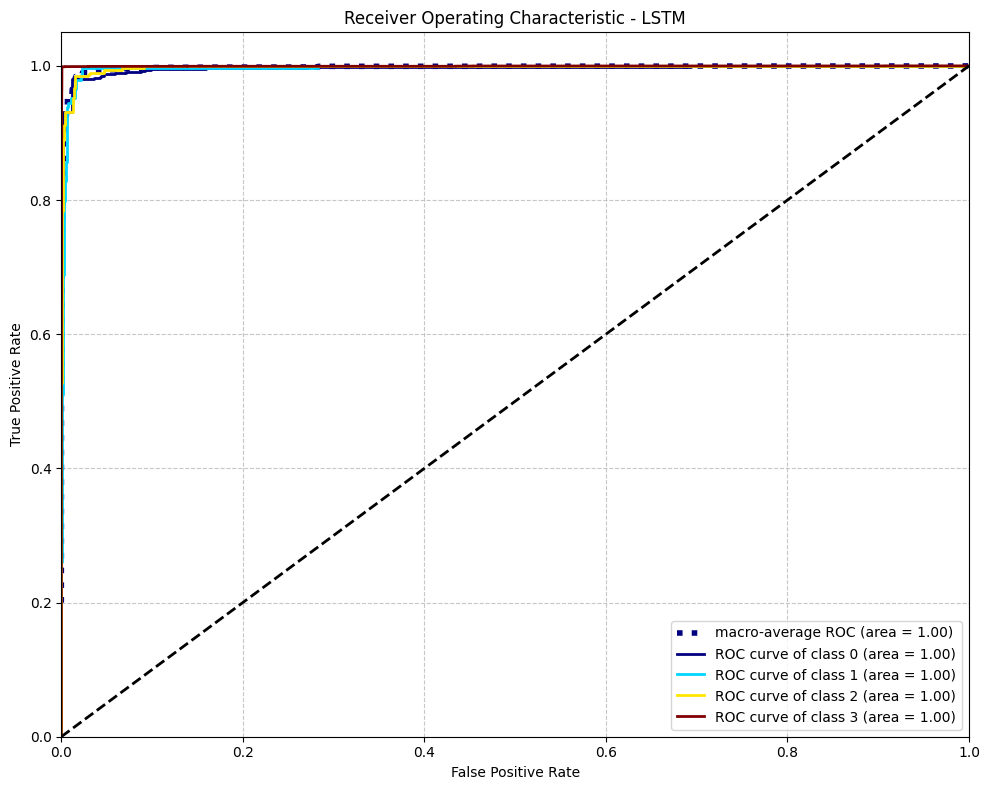

,accuracy,precision,recall,f1_score,auc
LSTM,0.936535,0.939602,0.936535,0.936325,0.997445
ANN,0.966439,0.981210,0.966439,0.971338,NaN
GRU,0.953688,0.956531,0.953688,0.953207,NaN
hybrid(GRU-LSTM),0.950257,0.953311,0.950257,0.949749,NaN
hybrid(GRU-ANN),0.927256,0.977400,0.927256,0.945939,NaN


In [ ]:
# Calculate and plot ROC for LSTM
n_classes = y_test_lstm.shape[1]
class_labels = [str(label) for label in sorted(np.unique(np.argmax(y_test_lstm, axis=1)))]

fig_roc_lstm, ax_roc_lstm = plt.subplots(figsize=(10, 8))
auc_lstm = plot_roc_curve(y_test_lstm, y_pred_lstm_prob, 'LSTM', class_labels, n_classes, ax_roc_lstm)
plt.tight_layout()
plt.show()

# Update model_performance with AUC for LSTM
model_performance.loc['auc', 'LSTM'] = auc_lstm

display(model_performance.T)

/tmp/ipykernel_14960/4218240784.py:35: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('jet', n_classes)(np.linspace(0, 1, n_classes))


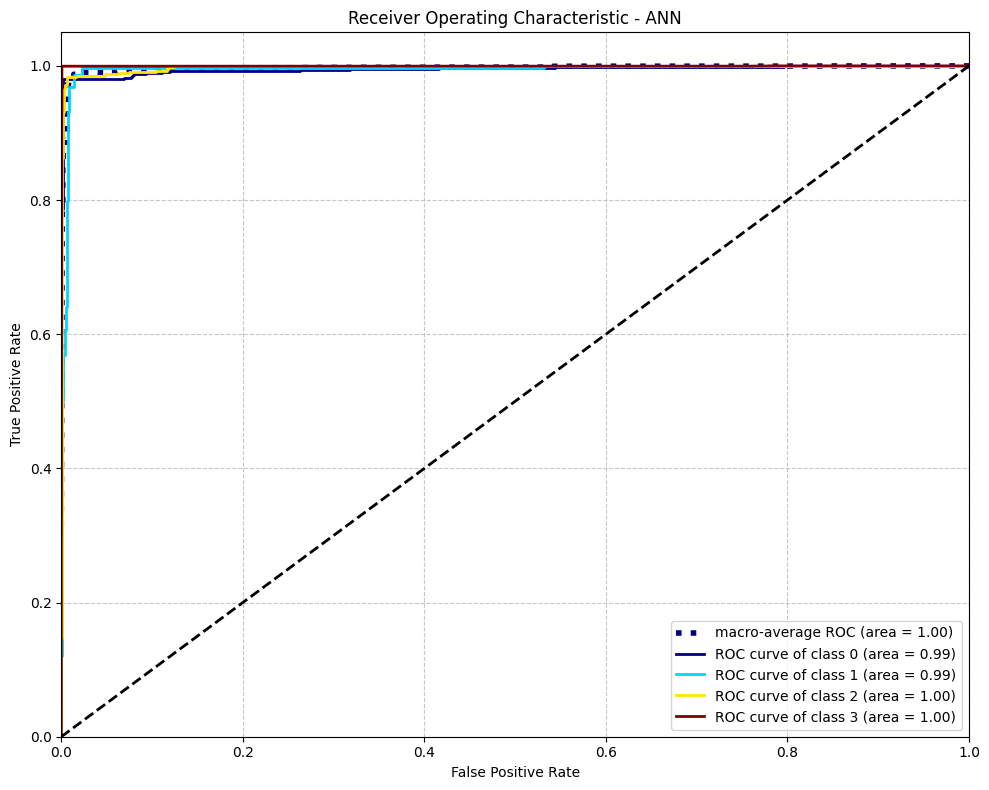

,accuracy,precision,recall,f1_score,auc
LSTM,0.936535,0.939602,0.936535,0.936325,0.997445
ANN,0.966439,0.981210,0.966439,0.971338,0.996714
GRU,0.953688,0.956531,0.953688,0.953207,NaN
hybrid(GRU-LSTM),0.950257,0.953311,0.950257,0.949749,NaN
hybrid(GRU-ANN),0.927256,0.977400,0.927256,0.945939,NaN


In [ ]:
# Calculate and plot ROC for ANN
n_classes = y_test_ann.shape[1]
class_labels = [str(label) for label in sorted(np.unique(np.argmax(y_test_ann, axis=1)))]

fig_roc_ann, ax_roc_ann = plt.subplots(figsize=(10, 8))
auc_ann = plot_roc_curve(y_test_ann, y_pred_ann_prob, 'ANN', class_labels, n_classes, ax_roc_ann)
plt.tight_layout()
plt.show()

# Update model_performance with AUC for ANN
model_performance.loc['auc', 'ANN'] = auc_ann

display(model_performance.T)

/tmp/ipykernel_14960/4218240784.py:35: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('jet', n_classes)(np.linspace(0, 1, n_classes))


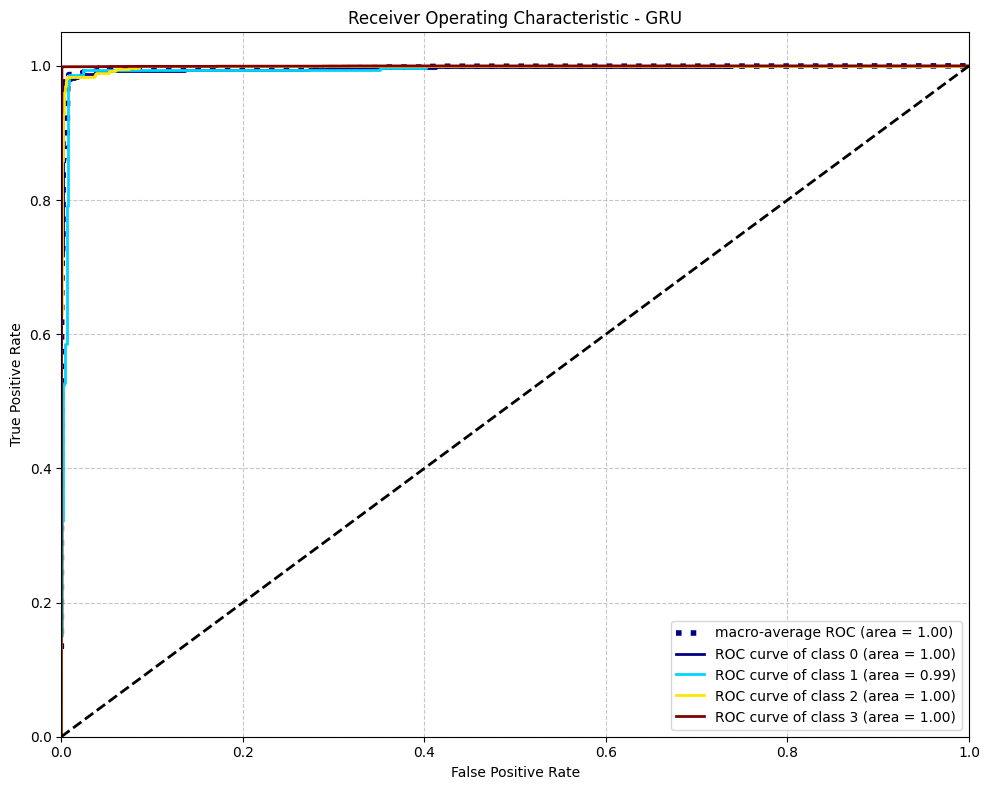

,accuracy,precision,recall,f1_score,auc
LSTM,0.936535,0.939602,0.936535,0.936325,0.997445
ANN,0.966439,0.981210,0.966439,0.971338,0.996714
GRU,0.953688,0.956531,0.953688,0.953207,0.996980
hybrid(GRU-LSTM),0.950257,0.953311,0.950257,0.949749,NaN
hybrid(GRU-ANN),0.927256,0.977400,0.927256,0.945939,NaN


In [ ]:
# Calculate and plot ROC for GRU
n_classes = y_test_lstm.shape[1] # Reusing y_test_lstm as it's the target for GRU as well
class_labels = [str(label) for label in sorted(np.unique(np.argmax(y_test_lstm, axis=1)))]

fig_roc_gru, ax_roc_gru = plt.subplots(figsize=(10, 8))
auc_gru = plot_roc_curve(y_test_lstm, y_pred_gru_prob, 'GRU', class_labels, n_classes, ax_roc_gru)
plt.tight_layout()
plt.show()

# Update model_performance with AUC for GRU
model_performance.loc['auc', 'GRU'] = auc_gru

display(model_performance.T)

706/706 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step


/tmp/ipykernel_14960/4218240784.py:35: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('jet', n_classes)(np.linspace(0, 1, n_classes))


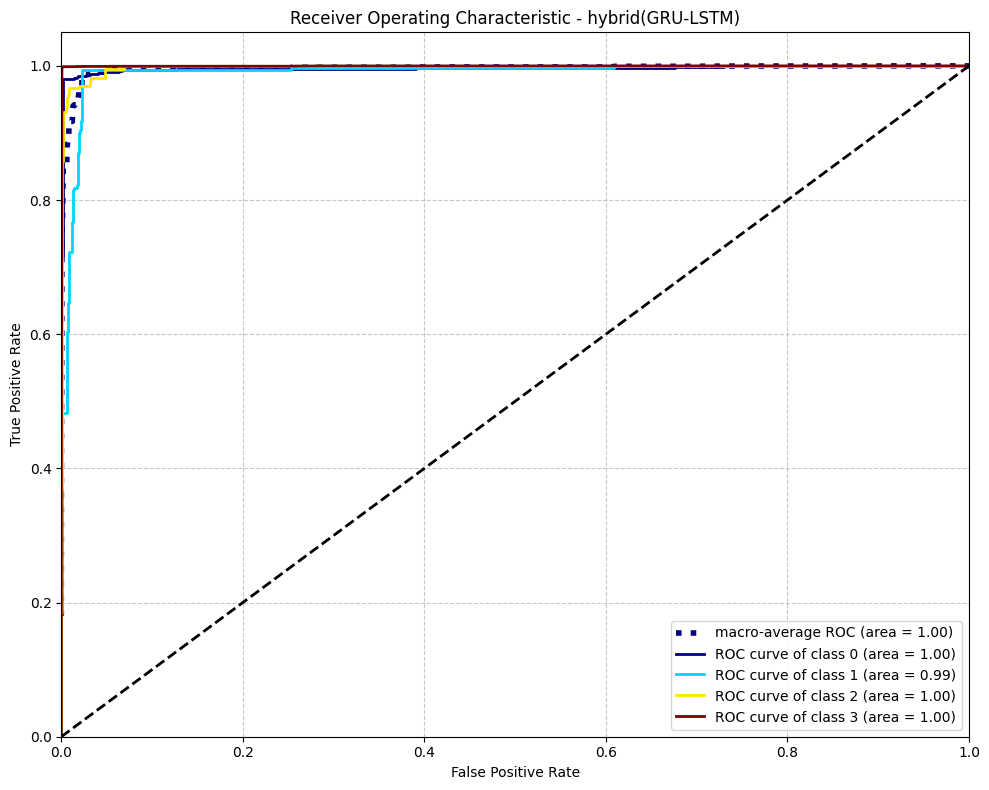

,accuracy,precision,recall,f1_score,auc
LSTM,0.936535,0.939602,0.936535,0.936325,0.997445
ANN,0.966439,0.981210,0.966439,0.971338,0.996714
GRU,0.953688,0.956531,0.953688,0.953207,0.996980
hybrid(GRU-LSTM),0.950257,0.953311,0.950257,0.949749,0.995960
hybrid(GRU-ANN),0.927256,0.977400,0.927256,0.945939,NaN


In [ ]:
# Ensure y_pred_hybrid_prob is generated for Hybrid GRU-LSTM
# This was previously only calculated as argmax. We need the probabilities for ROC.
y_pred_hybrid_prob = hybrid_model.predict(X_test_lstm)

# Calculate and plot ROC for Hybrid GRU-LSTM
n_classes = y_test_lstm.shape[1]
class_labels = [str(label) for label in sorted(np.unique(np.argmax(y_test_lstm, axis=1)))]

fig_roc_hybrid, ax_roc_hybrid = plt.subplots(figsize=(10, 8))
auc_hybrid = plot_roc_curve(y_test_lstm, y_pred_hybrid_prob, 'hybrid(GRU-LSTM)', class_labels, n_classes, ax_roc_hybrid)
plt.tight_layout()
plt.show()

# Update model_performance with AUC for Hybrid GRU-LSTM
model_performance.loc['auc', 'hybrid(GRU-LSTM)'] = auc_hybrid

display(model_performance.T)

/tmp/ipykernel_14960/4218240784.py:35: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('jet', n_classes)(np.linspace(0, 1, n_classes))


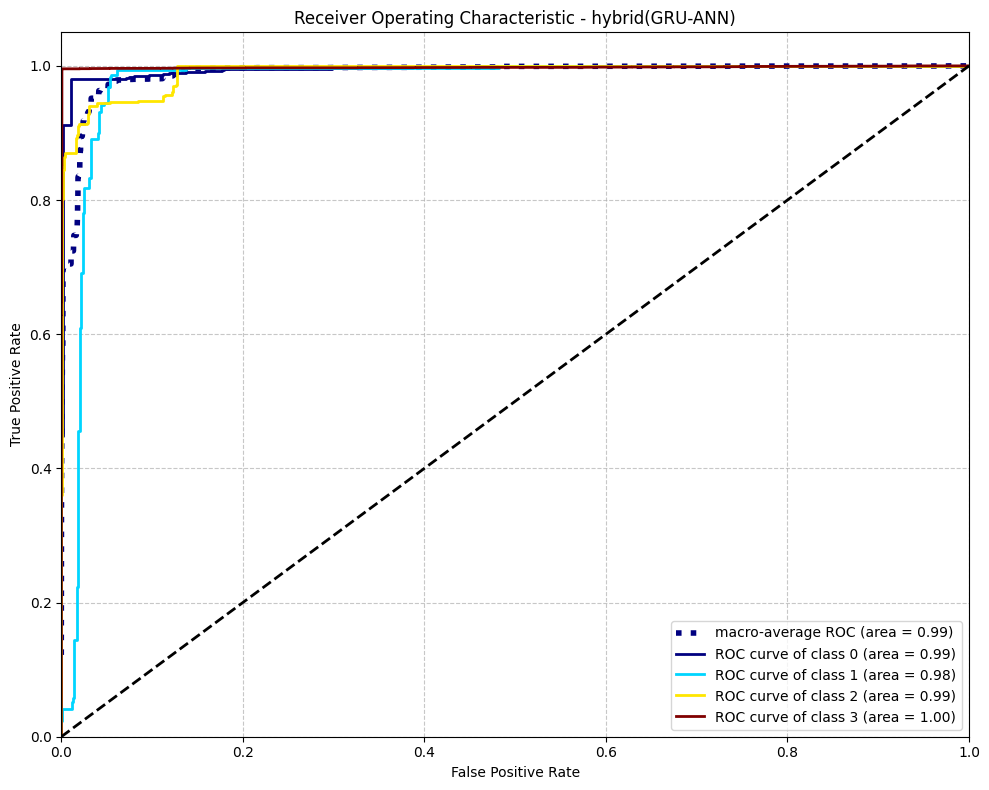

,accuracy,precision,recall,f1_score,auc
LSTM,0.936535,0.939602,0.936535,0.936325,0.997445
ANN,0.966439,0.981210,0.966439,0.971338,0.996714
GRU,0.953688,0.956531,0.953688,0.953207,0.996980
hybrid(GRU-LSTM),0.950257,0.953311,0.950257,0.949749,0.995960
hybrid(GRU-ANN),0.927256,0.977400,0.927256,0.945939,0.989792


In [ ]:
# Calculate and plot ROC for Hybrid GRU-ANN
n_classes = y_test_lstm.shape[1]
class_labels = [str(label) for label in sorted(np.unique(np.argmax(y_test_lstm, axis=1)))]

fig_roc_hybrid_gru_ann, ax_roc_hybrid_gru_ann = plt.subplots(figsize=(10, 8))
auc_hybrid_gru_ann = plot_roc_curve(y_test_lstm, y_pred_hybrid_gru_ann_prob, 'hybrid(GRU-ANN)', class_labels, n_classes, ax_roc_hybrid_gru_ann)
plt.tight_layout()
plt.show()

# Update model_performance with AUC for Hybrid GRU-ANN
model_performance.loc['auc', 'hybrid(GRU-ANN)'] = auc_hybrid_gru_ann

display(model_performance.T)

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, LSTM, GRU, Reshape, concatenate, Permute, multiply, Activation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
import numpy as np
import matplotlib.pyplot as plt

# --- Temporal Fusion Transformer (TFT) Implementation ---

# This is a simplified conceptual implementation of TFT components
# focusing on the attention mechanism for tabular data.
# A full TFT implementation is complex and often uses specialized libraries (e.g., PyTorch Forecasting, GluonTS)
# For this demonstration, we'll adapt its core ideas to a Keras sequential model structure.

# 1. Input preparation
# For TFT, we typically need static, known future, and historical inputs.
# For a simplified tabular case, we can treat current features as 'historical' and try to predict 'future' status.

# Reuse X_scaled and y_one_hot from previous steps
# X_scaled shape: (n_samples, n_features)
# y_one_hot shape: (n_samples, n_classes)

print("Preprocessing data for TFT...")

# Split data for TFT
X_train_tft, X_test_tft, y_train_tft, y_test_tft = train_test_split(
    X_scaled, y_one_hot, test_size=0.2, random_state=42, stratify=np.argmax(y_one_hot, axis=1)
)

# Reshape for sequence models (even if sequence length is 1 for tabular)
# (samples, timesteps, features)
# For TFT like approach with tabular data, we might consider each feature as a 'timestep'
# or create a dummy timestep dimension if the model expects it.
# Let's consider 1 timestep, and features as feature dimension for now.
# If features are to be treated as a sequence, reshape to (samples, num_features, 1)
# If we want a 'true' sequence for TFT, we'd need actual time-series data, which X_balanced isn't directly.
# For now, we'll treat it as a sequence of length 1 with the features in the last dimension.

timesteps = 1 # Each sample is a single observation in this tabular context
input_dim = X_train_tft.shape[1] # Number of features
n_classes = y_train_tft.shape[1] # Number of output classes

X_train_tft_reshaped = X_train_tft.reshape(-1, timesteps, input_dim)
X_test_tft_reshaped = X_test_tft.reshape(-1, timesteps, input_dim)

print(f"X_train_tft_reshaped shape: {X_train_tft_reshaped.shape}")
print(f"y_train_tft shape: {y_train_tft.shape}")
print(f"X_test_tft_reshaped shape: {X_test_tft_reshaped.shape}")
print(f"y_test_tft shape: {y_test_tft.shape}")

print("\nBuilding simplified TFT-like model...")

def create_tft_like_model(input_shape, output_dim, head_size=128, num_heads=4, ff_dim=4, num_transformer_blocks=1, mlp_units=[64], dropout=0.2, mlp_dropout=0.2):
    inputs = Input(shape=input_shape)

    # --- Gated Residual Network (GRN) for Feature Transformation (Simplified) ---
    # This part typically involves a non-linear transformation followed by gating.
    # For simplicity, we'll use a Dense layer with activation and a skip connection.
    x = Dense(head_size * num_heads, activation="relu")(inputs)
    x = Dense(head_size * num_heads, activation="linear")(x)

    # Optionally add gating mechanism: output = GLU(input, W_glu) + input_transformed
    # For simplicity, we'll use a direct residual connection after initial dense layers.
    # A true GRN would have a more explicit gating component.

    # --- Multi-head Self-Attention ---
    # Using a standard MultiHeadAttention if available or implementing a simplified version.
    # Keras provides MultiHeadAttention layer in tf.keras.layers

    # The input to attention is typically a sequence. Here, our 'sequence length' is 1.
    # So, we can directly apply attention to the (batch, 1, features) input.

    # Apply a dense layer to transform features for attention (if needed, or directly use input)
    attention_input = Dense(head_size * num_heads)(x)

    # Create multi-head attention layer
    multi_head_attention = tf.keras.layers.MultiHeadAttention(
        num_heads=num_heads, key_dim=head_size, dropout=dropout
    )(attention_input, attention_input, attention_input)

    # Add & Norm (simplified)
    attention_output = tf.keras.layers.LayerNormalization(epsilon=1e-6)(attention_input + multi_head_attention)

    # Feed Forward Block (simplified)
    ffn_output = Sequential([
        Dense(ff_dim, activation="relu"),
        Dense(head_size * num_heads),
    ])(attention_output)
    ffn_output = tf.keras.layers.LayerNormalization(epsilon=1e-6)(attention_output + ffn_output)

    # Global Context Enrichment (simplified, often involves pooling or another GRN)
    # For tabular, we might just flatten and pass through MLP.

    x = tf.keras.layers.Flatten()(ffn_output)

    # --- Output layer ---
    # Final MLP for prediction
    for unit in mlp_units:
        x = Dense(unit, activation="relu")(x)
        x = Dropout(mlp_dropout)(x)

    outputs = Dense(output_dim, activation="softmax")(x)

    return Model(inputs=inputs, outputs=outputs)

# Create the TFT-like model
tft_model = create_tft_like_model(
    input_shape=(timesteps, input_dim),
    output_dim=n_classes,
    head_size=32, # Smaller head size for tabular data with fewer features
    num_heads=4,
    ff_dim=128,
    num_transformer_blocks=1,
    mlp_units=[64, 32],
    dropout=0.1,
    mlp_dropout=0.1
)

# Compile the model
tft_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

tft_model.summary()
print("Simplified TFT-like model built successfully!")

Preprocessing data for TFT...
X_train_tft_reshaped shape: (90342, 1, 9)
y_train_tft shape: (90342, 4)
X_test_tft_reshaped shape: (22586, 1, 9)
y_test_tft shape: (22586, 4)

Building simplified TFT-like model...


Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_10      │ (None, 1, 9)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 1, 128)    │      1,280 │ input_layer_10[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_17 (Dense)    │ (None, 1, 128)    │     16,512 │ dense_16[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_18 (Dense)    │ (None, 1, 128)    │     16,512 │ dense_17[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 1, 128)    │     66,048 │ dense_18[0][0],   │
│ (MultiHeadAttentio… │                   │            │ dense_18[0][0],   │
│                     │                   │            │ dense_18[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 1, 128)    │          0 │ dense_18[0][0],   │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 1, 128)    │        256 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_10       │ (None, 1, 128)    │     33,024 │ layer_normalizat… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 1, 128)    │          0 │ layer_normalizat… │
│                     │                   │            │ sequential_10[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 1, 128)    │        256 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 128)       │          0 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_21 (Dense)    │ (None, 64)        │      8,256 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_21          │ (None, 64)        │          0 │ dense_21[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_22 (Dense)    │ (None, 32)        │      2,080 │ dropout_21[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_22          │ (None, 32)        │          0 │ dense_22[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_23 (Dense)    │ (None, 4)         │        132 │ dropout_22[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 144,356 (563.89 KB)

 Trainable params: 144,356 (563.89 KB)

 Non-trainable params: 0 (0.00 B)

Simplified TFT-like model built successfully!



Training TFT-like model...
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis 3 of a tensor of shape (None, 4, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


2541/2541 ━━━━━━━━━━━━━━━━━━━━ 25s 6ms/step - accuracy: 0.8727 - loss: 0.2842 - val_accuracy: 0.8975 - val_loss: 0.2049
Epoch 2/20
2541/2541 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.8882 - loss: 0.2465 - val_accuracy: 0.8968 - val_loss: 0.2338
Epoch 3/20
2541/2541 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.8930 - loss: 0.2239 - val_accuracy: 0.9004 - val_loss: 0.2276
Epoch 4/20
2541/2541 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8902 - loss: 0.2412 - val_accuracy: 0.8892 - val_loss: 0.2486
Epoch 5/20
2541/2541 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8898 - loss: 0.2339 - val_accuracy: 0.8985 - val_loss: 0.2433
Epoch 6/20
2541/2541 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8969 - loss: 0.2219 - val_accuracy: 0.8980 - val_loss: 0.2572
Epoch 7/20
2541/2541 ━━━━━━━━━━━━━━━━━━━━ 20s 4ms/step - accuracy: 0.8854 - loss: 0.2430 - val_accuracy: 0.9049 - val_loss: 0.2188
Epoch 8/20
2541/2541 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9005 - loss: 0.2059 - val

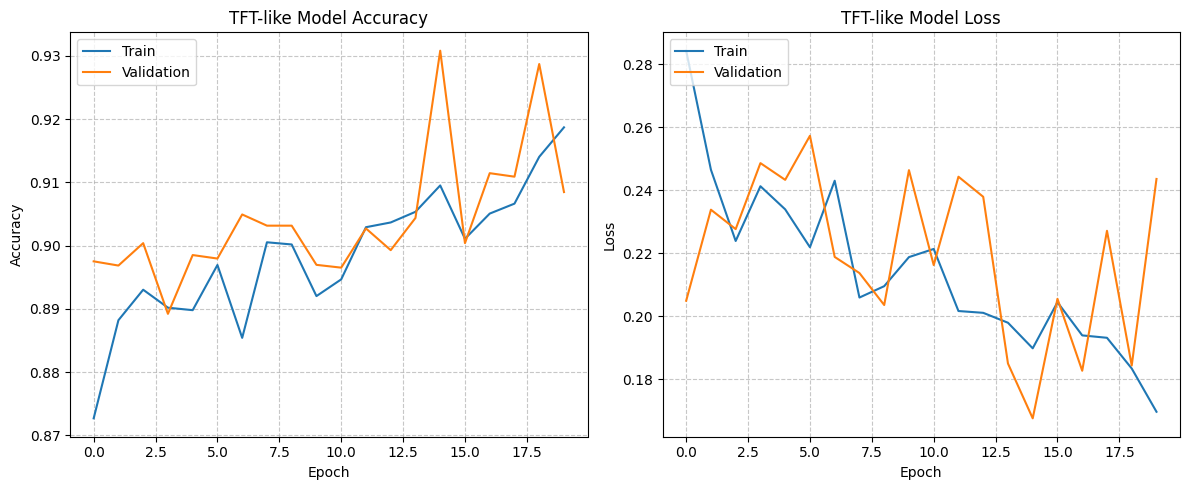


--- TFT-like Model Performance ---
Test Accuracy: 0.9092


/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis 3 of a tensor of shape (32, 4, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


706/706 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
Classification Report for TFT-like Model:
              precision    recall  f1-score   support

           0       0.77      0.97      0.86      2294
           1       0.18      1.00      0.30       292
           2       0.99      0.80      0.89     10000
           3       1.00      1.00      1.00     10000

    accuracy                           0.91     22586
   macro avg       0.74      0.94      0.76     22586
weighted avg       0.96      0.91      0.93     22586


TFT-like Model Precision (weighted): 0.9634
TFT-like Model Recall (weighted): 0.9092
TFT-like Model F1 Score (weighted): 0.9270


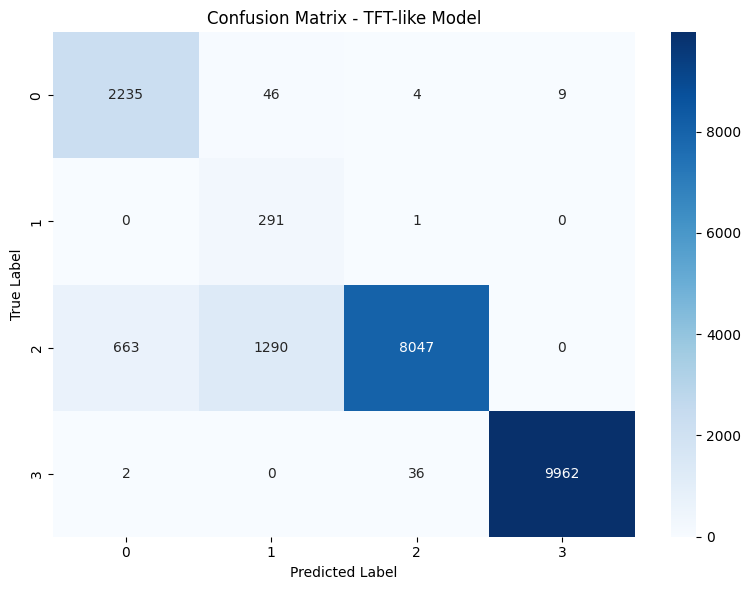

/tmp/ipykernel_14960/4218240784.py:35: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('jet', n_classes)(np.linspace(0, 1, n_classes))


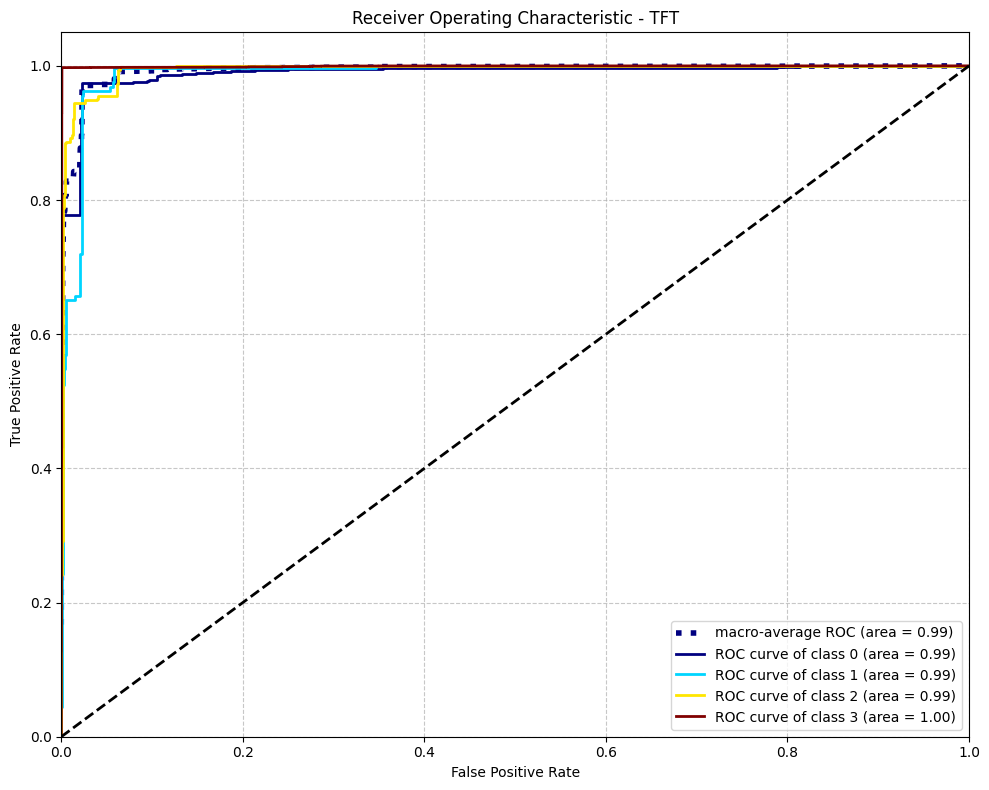


Updated model_performance with TFT results:


,accuracy,precision,recall,f1_score,auc
LSTM,0.936535,0.939602,0.936535,0.936325,0.997445
ANN,0.966439,0.981210,0.966439,0.971338,0.996714
GRU,0.953688,0.956531,0.953688,0.953207,0.996980
hybrid(GRU-LSTM),0.950257,0.953311,0.950257,0.949749,0.995960
hybrid(GRU-ANN),0.927256,0.977400,0.927256,0.945939,0.989792
TFT,0.909192,0.963449,0.909192,0.926984,0.993048


In [ ]:
print("\nTraining TFT-like model...")

history_tft = tft_model.fit(
    X_train_tft_reshaped, y_train_tft,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1,
    class_weight=class_weights_dict # Apply class weights
)

print("TFT-like model training complete!")

# Plot training history
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history_tft.history['accuracy'])
plt.plot(history_tft.history['val_accuracy'])
plt.title('TFT-like Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_tft.history['loss'])
plt.plot(history_tft.history['val_loss'])
plt.title('TFT-like Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Evaluate the model on the test set
loss_tft, accuracy_tft = tft_model.evaluate(X_test_tft_reshaped, y_test_tft, verbose=0)
print(f"\n--- TFT-like Model Performance ---")
print(f"Test Accuracy: {accuracy_tft:.4f}")

y_pred_tft_prob = tft_model.predict(X_test_tft_reshaped)
y_pred_tft = np.argmax(y_pred_tft_prob, axis=1)
y_true_tft = np.argmax(y_test_tft, axis=1)

print("Classification Report for TFT-like Model:")
print(classification_report(y_true_tft, y_pred_tft))

# Calculate individual metrics
precision_tft = precision_score(y_true_tft, y_pred_tft, average='weighted')
recall_tft = recall_score(y_true_tft, y_pred_tft, average='weighted')
f1_tft = f1_score(y_true_tft, y_pred_tft, average='weighted')

print(f"\nTFT-like Model Precision (weighted): {precision_tft:.4f}")
print(f"TFT-like Model Recall (weighted): {recall_tft:.4f}")
print(f"TFT-like Model F1 Score (weighted): {f1_tft:.4f}")

# Add TFT performance to model_performance dictionary
model_performance['TFT'] = {
    'accuracy': accuracy_tft,
    'precision': precision_tft,
    'recall': recall_tft,
    'f1_score': f1_tft
}

# Plot Confusion Matrix for TFT
class_labels_tft = [str(label) for label in sorted(np.unique(np.argmax(y_test_tft, axis=1)))]

plt.figure(figsize=(8, 6))
cm_tft = confusion_matrix(y_true_tft, y_pred_tft)
sns.heatmap(cm_tft, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels_tft, yticklabels=class_labels_tft)
plt.title(f'Confusion Matrix - TFT-like Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

# Calculate and plot ROC for TFT
n_classes_tft = y_test_tft.shape[1]
fig_roc_tft, ax_roc_tft = plt.subplots(figsize=(10, 8))
auc_tft = plot_roc_curve(y_test_tft, y_pred_tft_prob, 'TFT', class_labels_tft, n_classes_tft, ax_roc_tft)
plt.tight_layout()
plt.show()

# Update model_performance with AUC for TFT
model_performance.loc['auc', 'TFT'] = auc_tft

print("\nUpdated model_performance with TFT results:")
display(model_performance.T)

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, LayerNormalization, MultiHeadAttention, GlobalAveragePooling1D
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Informer-like Model Implementation ---

# Informer is typically designed for long sequence time series forecasting.
# For tabular classification, we need to adapt its core ideas.
# Key components of Informer include: Encoder-Decoder architecture, ProbSparse self-attention,
# and self-attention distilling.
# For this tabular context, we will focus on building an encoder-only architecture
# with standard MultiHeadAttention as a proxy for ProbSparse, and a feed-forward network.

print("Preprocessing data for Informer-like model...")

# Reuse X_scaled and y_one_hot from previous steps
# X_scaled shape: (n_samples, n_features)
# y_one_hot shape: (n_samples, n_classes)

# Split data for Informer
X_train_informer, X_test_informer, y_train_informer, y_test_informer = train_test_split(
    X_scaled, y_one_hot, test_size=0.2, random_state=42, stratify=np.argmax(y_one_hot, axis=1)
)

# Reshape for sequence models: (samples, timesteps, features)
# For tabular data, we'll treat each feature as a timestep within a sequence of length equal to number of features.
# This is a common adaptation for Transformer models on tabular data where true time series is not present.
sequence_length = X_train_informer.shape[1] # Each feature is a 'step'
input_features = 1 # Each step has 1 feature (the scaled value)
n_classes = y_train_informer.shape[1] # Number of output classes

X_train_informer_reshaped = X_train_informer.reshape(-1, sequence_length, input_features)
X_test_informer_reshaped = X_test_informer.reshape(-1, sequence_length, input_features)

print(f"X_train_informer_reshaped shape: {X_train_informer_reshaped.shape}")
print(f"y_train_informer shape: {y_train_informer.shape}")
print(f"X_test_informer_reshaped shape: {X_test_informer_reshaped.shape}")
print(f"y_test_informer shape: {y_test_informer.shape}")

print("\nBuilding simplified Informer-like model...")

def create_informer_like_model(input_shape, output_dim, embed_dim=64, num_heads=4, ff_dim=128, dropout_rate=0.1):
    inputs = Input(shape=input_shape)
    x = inputs

    # Positional Encoding (simplified: typically added to embeddings, here applied to raw input)
    # For fixed length tabular data, simple learned positional embeddings can be used.
    # For simplicity here, we assume the order of features implicitly provides some positional info
    # or we rely on the attention mechanism itself to learn feature interactions.

    # Embed each feature (or just pass through a dense layer if input_features is 1)
    # The input here is (batch, sequence_length, input_features)
    # We want to project the last dimension to embed_dim
    if input_shape[-1] != embed_dim:
        x = Dense(embed_dim)(x) # Project input features to embed_dim

    # Encoder Block (self-attention + feed-forward)
    # Multi-head Self Attention
    attn_output = MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)(x, x)
    attn_output = Dropout(dropout_rate)(attn_output)
    attn_output = LayerNormalization(epsilon=1e-6)(x + attn_output) # Add & Norm

    # Feed Forward Network
    ffn_output = Dense(ff_dim, activation="relu")(attn_output)
    ffn_output = Dense(embed_dim)(ffn_output) # Project back to embed_dim
    ffn_output = Dropout(dropout_rate)(ffn_output)
    x = LayerNormalization(epsilon=1e-6)(attn_output + ffn_output) # Add & Norm

    # Pooling layer to get a fixed-size representation before classification head
    x = GlobalAveragePooling1D()(x)

    # Classification Head
    outputs = Dense(output_dim, activation="softmax")(x)

    return Model(inputs=inputs, outputs=outputs)

informer_model = create_informer_like_model(
    input_shape=(sequence_length, input_features),
    output_dim=n_classes,
    embed_dim=32, # Embedding dimension for features
    num_heads=4,
    ff_dim=64,
    dropout_rate=0.1
)

informer_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

informer_model.summary()
print("Simplified Informer-like model built successfully!")

Preprocessing data for Informer-like model...
X_train_informer_reshaped shape: (90342, 9, 1)
y_train_informer shape: (90342, 4)
X_test_informer_reshaped shape: (22586, 9, 1)
y_test_informer shape: (22586, 4)

Building simplified Informer-like model...


Model: "functional_12"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_12      │ (None, 9, 1)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_24 (Dense)    │ (None, 9, 32)     │         64 │ input_layer_12[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 9, 32)     │     16,800 │ dense_24[0][0],   │
│ (MultiHeadAttentio… │                   │            │ dense_24[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_24          │ (None, 9, 32)     │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 9, 32)     │          0 │ dense_24[0][0],   │
│                     │                   │            │ dropout_24[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 9, 32)     │         64 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_25 (Dense)    │ (None, 9, 64)     │      2,112 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_26 (Dense)    │ (None, 9, 32)     │      2,080 │ dense_25[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_25          │ (None, 9, 32)     │          0 │ dense_26[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 9, 32)     │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_25[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 9, 32)     │         64 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_27 (Dense)    │ (None, 4)         │        132 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 21,316 (83.27 KB)

 Trainable params: 21,316 (83.27 KB)

 Non-trainable params: 0 (0.00 B)

Simplified Informer-like model built successfully!



Training Informer-like model...
Epoch 1/20
2541/2541 ━━━━━━━━━━━━━━━━━━━━ 24s 6ms/step - accuracy: 0.7386 - loss: 0.5454 - val_accuracy: 0.8353 - val_loss: 0.5068
Epoch 2/20
2541/2541 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8395 - loss: 0.3597 - val_accuracy: 0.8540 - val_loss: 0.4519
Epoch 3/20
2541/2541 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8625 - loss: 0.3055 - val_accuracy: 0.8692 - val_loss: 0.3067
Epoch 4/20
2541/2541 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8696 - loss: 0.2866 - val_accuracy: 0.8727 - val_loss: 0.2571
Epoch 5/20
2541/2541 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8780 - loss: 0.2702 - val_accuracy: 0.8875 - val_loss: 0.2572
Epoch 6/20
2541/2541 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8861 - loss: 0.2449 - val_accuracy: 0.8950 - val_loss: 0.2331
Epoch 7/20
2541/2541 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8873 - loss: 0.2443 - val_accuracy: 0.8822 - val_loss: 0.2880
Epoch 8/20
2541/2541 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/st

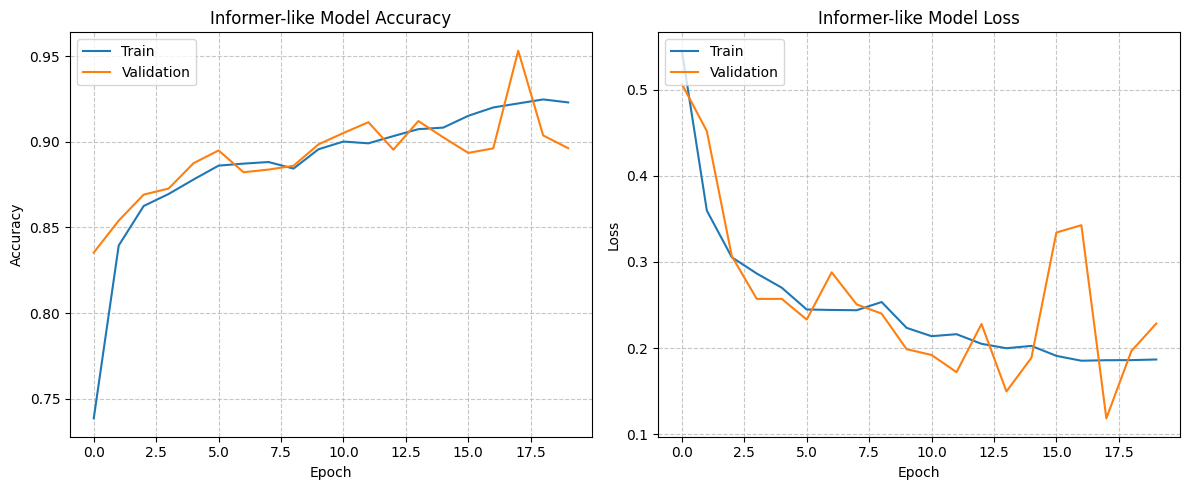


--- Informer-like Model Performance ---
Test Accuracy: 0.8971
706/706 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
Classification Report for Informer-like Model:
              precision    recall  f1-score   support

           0       0.78      0.98      0.87      2294
           1       0.15      0.96      0.26       292
           2       0.99      0.78      0.88     10000
           3       1.00      0.99      0.99     10000

    accuracy                           0.90     22586
   macro avg       0.73      0.93      0.75     22586
weighted avg       0.96      0.90      0.92     22586


Informer-like Model Precision (weighted): 0.9624
Informer-like Model Recall (weighted): 0.8971
Informer-like Model F1 Score (weighted): 0.9194


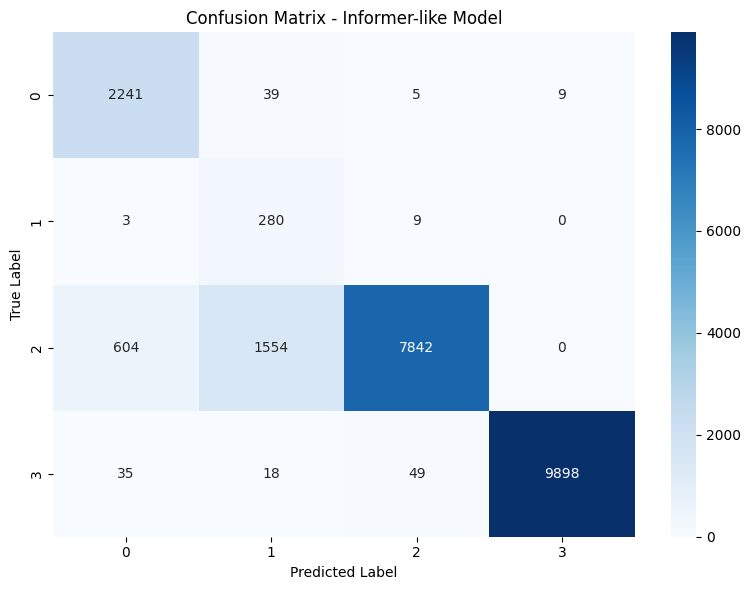

/tmp/ipykernel_14960/4218240784.py:35: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('jet', n_classes)(np.linspace(0, 1, n_classes))


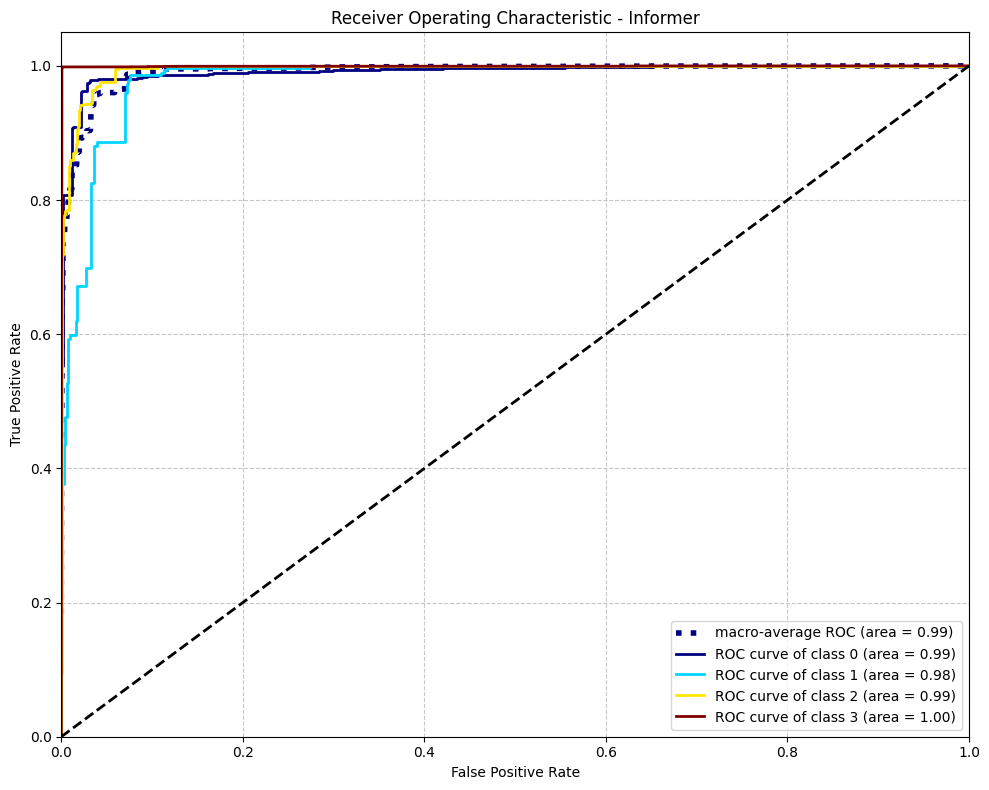


Updated model_performance with Informer results:


,accuracy,precision,recall,f1_score,auc
LSTM,0.936535,0.939602,0.936535,0.936325,0.997445
ANN,0.966439,0.981210,0.966439,0.971338,0.996714
GRU,0.953688,0.956531,0.953688,0.953207,0.996980
hybrid(GRU-LSTM),0.950257,0.953311,0.950257,0.949749,0.995960
hybrid(GRU-ANN),0.927256,0.977400,0.927256,0.945939,0.989792
TFT,0.909192,0.963449,0.909192,0.926984,0.993048
Informer,0.897060,0.962438,0.897060,0.919364,0.991579


In [ ]:
print("\nTraining Informer-like model...")

history_informer = informer_model.fit(
    X_train_informer_reshaped, y_train_informer,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1,
    class_weight=class_weights_dict # Apply class weights
)

print("Informer-like model training complete!")

# Plot training history
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history_informer.history['accuracy'])
plt.plot(history_informer.history['val_accuracy'])
plt.title('Informer-like Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_informer.history['loss'])
plt.plot(history_informer.history['val_loss'])
plt.title('Informer-like Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Evaluate the model on the test set
loss_informer, accuracy_informer = informer_model.evaluate(X_test_informer_reshaped, y_test_informer, verbose=0)
print(f"\n--- Informer-like Model Performance ---")
print(f"Test Accuracy: {accuracy_informer:.4f}")

y_pred_informer_prob = informer_model.predict(X_test_informer_reshaped)
y_pred_informer = np.argmax(y_pred_informer_prob, axis=1)
y_true_informer = np.argmax(y_test_informer, axis=1)

print("Classification Report for Informer-like Model:")
print(classification_report(y_true_informer, y_pred_informer))

# Calculate individual metrics
precision_informer = precision_score(y_true_informer, y_pred_informer, average='weighted')
recall_informer = recall_score(y_true_informer, y_pred_informer, average='weighted')
f1_informer = f1_score(y_true_informer, y_pred_informer, average='weighted')

print(f"\nInformer-like Model Precision (weighted): {precision_informer:.4f}")
print(f"Informer-like Model Recall (weighted): {recall_informer:.4f}")
print(f"Informer-like Model F1 Score (weighted): {f1_informer:.4f}")

# Add Informer performance to model_performance dictionary
model_performance['Informer'] = {
    'accuracy': accuracy_informer,
    'precision': precision_informer,
    'recall': recall_informer,
    'f1_score': f1_informer
}

# Plot Confusion Matrix for Informer
class_labels_informer = [str(label) for label in sorted(np.unique(np.argmax(y_test_informer, axis=1)))]

plt.figure(figsize=(8, 6))
cm_informer = confusion_matrix(y_true_informer, y_pred_informer)
sns.heatmap(cm_informer, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels_informer, yticklabels=class_labels_informer)
plt.title(f'Confusion Matrix - Informer-like Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

# Calculate and plot ROC for Informer
n_classes_informer = y_test_informer.shape[1]
fig_roc_informer, ax_roc_informer = plt.subplots(figsize=(10, 8))
auc_informer = plot_roc_curve(y_test_informer, y_pred_informer_prob, 'Informer', class_labels_informer, n_classes_informer, ax_roc_informer)
plt.tight_layout()
plt.show()

# Update model_performance with AUC for Informer
model_performance.loc['auc', 'Informer'] = auc_informer

print("\nUpdated model_performance with Informer results:")
display(model_performance.T)

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Embedding, Concatenate, MultiHeadAttention, Dropout, LayerNormalization, Flatten
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- TabTransformer Implementation ---

# TabTransformer is designed for tabular data, using a transformer encoder
# over categorical features, while continuous features are passed through an MLP.

print("Preprocessing data for TabTransformer...")

# Separate categorical and numerical features for TabTransformer
# Assuming 'data_balanced' is available and has 'status_encoded' as target.
# We need to re-identify original categorical features and numerical features.

# Original numerical columns were: 'cpu_avg', 'cpu_max', 'mem_avg', 'mem_max', 'disk_io_percent', 'net_in', 'net_out'
# There are 7 numerical features after dropping ID/status columns.
# Let's assume the first 'n' columns in X_balanced are numerical and the rest are categorical after some preprocessing.
# In our case, all features are numerical. So we need to adapt TabTransformer.
# A common adaptation for purely numerical tabular data is to bin numerical features
# to create pseudo-categorical features, or simply use the Transformer for interactions
# between continuous features treated as a sequence.

# Given the current dataset (X_balanced), all features are numerical.
# For TabTransformer, we'll treat them all as continuous, but we can
# still leverage the self-attention mechanism by creating feature embeddings for each numerical feature.

# Identify numerical features from X_balanced (assuming all are numerical)
numerical_features = X_balanced.columns.tolist()

# Since there are no explicit categorical features identified in the original data schema,
# we will treat each numerical feature as if it were a 'feature token'
# and apply an embedding to it before passing it through the transformer blocks.
# This is an adaptation to make TabTransformer applicable to a purely numerical dataset.

# Split data
X_train_tabt, X_test_tabt, y_train_tabt, y_test_tabt = train_test_split(
    X_balanced, y_one_hot, test_size=0.2, random_state=42, stratify=np.argmax(y_one_hot, axis=1)
)

n_classes = y_train_tabt.shape[1]
num_features = X_train_tabt.shape[1]

# For TabTransformer, we often need embeddings for each feature.
# Since our features are continuous, we'll use a simple Dense layer to project each feature to an embedding space.

print(f"X_train_tabt shape: {X_train_tabt.shape}")
print(f"y_train_tabt shape: {y_train_tabt.shape}")
print(f"X_test_tabt shape: {X_test_tabt.shape}")
print(f"y_test_tabt shape: {y_test_tabt.shape}")

print("\nBuilding TabTransformer-like model...")

def create_tabtransformer_like_model(num_features, output_dim,
                                     embed_dim=32, num_heads=4, ff_dim=64,
                                     num_transformer_blocks=2, dropout_rate=0.1,
                                     mlp_units=[128, 64]):

    inputs = Input(shape=(num_features,))

    # --- Feature Embeddings for Continuous Features ---
    # Each feature value will be projected to an embedding space.
    # We can use a shared dense layer for all features or individual ones.
    # For simplicity, we'll apply a dense layer to each feature, then concatenate.

    # Reshape input to (batch_size, num_features, 1) to treat each feature as a 'token'
    x = Reshape((num_features, 1))(inputs)

    # Project each feature value into an embedding dimension
    feature_embeddings = Dense(embed_dim)(x)

    # --- Transformer Encoder Blocks ---
    transformer_input = feature_embeddings

    for _ in range(num_transformer_blocks):
        # Multi-Head Self-Attention
        attn_output = MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)(
            transformer_input, transformer_input
        )
        attn_output = Dropout(dropout_rate)(attn_output)
        attn_output = LayerNormalization(epsilon=1e-6)(transformer_input + attn_output) # Add & Norm

        # Feed Forward Network
        ffn_output = Dense(ff_dim, activation="relu")(attn_output)
        ffn_output = Dense(embed_dim)(ffn_output)
        ffn_output = Dropout(dropout_rate)(ffn_output)
        transformer_input = LayerNormalization(epsilon=1e-6)(attn_output + ffn_output) # Add & Norm

    # --- Concat and MLP Head ---
    # Flatten the output from the transformer blocks
    x = Flatten()(transformer_input)

    # Final MLP for classification
    for units in mlp_units:
        x = Dense(units, activation="relu")(x)
        x = Dropout(dropout_rate)(x)

    outputs = Dense(output_dim, activation="softmax")(x)

    return Model(inputs=inputs, outputs=outputs)

tabtransformer_model = create_tabtransformer_like_model(
    num_features=num_features,
    output_dim=n_classes,
    embed_dim=32,
    num_heads=4,
    ff_dim=64,
    num_transformer_blocks=2,
    dropout_rate=0.1,
    mlp_units=[128, 64]
)

tabtransformer_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

tabtransformer_model.summary()
print("Simplified TabTransformer-like model built successfully!")

Preprocessing data for TabTransformer...
X_train_tabt shape: (90342, 9)
y_train_tabt shape: (90342, 4)
X_test_tabt shape: (22586, 9)
y_test_tabt shape: (22586, 4)

Building TabTransformer-like model...


Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_13      │ (None, 9)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 9, 1)      │          0 │ input_layer_13[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_28 (Dense)    │ (None, 9, 32)     │         64 │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 9, 32)     │     16,800 │ dense_28[0][0],   │
│ (MultiHeadAttentio… │                   │            │ dense_28[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_27          │ (None, 9, 32)     │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 9, 32)     │          0 │ dense_28[0][0],   │
│                     │                   │            │ dropout_27[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 9, 32)     │         64 │ add_4[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_29 (Dense)    │ (None, 9, 64)     │      2,112 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_30 (Dense)    │ (None, 9, 32)     │      2,080 │ dense_29[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_28          │ (None, 9, 32)     │          0 │ dense_30[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_5 (Add)         │ (None, 9, 32)     │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_28[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 9, 32)     │         64 │ add_5[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 9, 32)     │     16,800 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_30          │ (None, 9, 32)     │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_6 (Add)         │ (None, 9, 32)     │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_30[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 9, 32)     │         64 │ add_6[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_31 (Dense)    │ (None, 9, 64)     │      2,112 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_32 (Dense)    │ (None, 9, 32)     │      2,080 │ dense_31[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_31          │ (None, 9, 32)     │          0 │ dense_32[0][0]  

 Total params: 87,812 (343.02 KB)

 Trainable params: 87,812 (343.02 KB)

 Non-trainable params: 0 (0.00 B)

Simplified TabTransformer-like model built successfully!



Training TabTransformer-like model...
Epoch 1/20
2541/2541 ━━━━━━━━━━━━━━━━━━━━ 34s 9ms/step - accuracy: 0.3981 - loss: 1.0081 - val_accuracy: 0.4586 - val_loss: 1.1378
Epoch 2/20
2541/2541 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - accuracy: 0.4326 - loss: 0.9878 - val_accuracy: 0.4586 - val_loss: 1.1808
Epoch 3/20
2541/2541 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - accuracy: 0.4347 - loss: 0.9831 - val_accuracy: 0.4586 - val_loss: 1.1908
Epoch 4/20
2541/2541 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - accuracy: 0.4465 - loss: 0.9821 - val_accuracy: 0.4586 - val_loss: 1.1492
Epoch 5/20
2541/2541 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - accuracy: 0.4421 - loss: 0.9821 - val_accuracy: 0.4586 - val_loss: 1.1398
Epoch 6/20
2541/2541 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - accuracy: 0.2905 - loss: 1.1943 - val_accuracy: 0.4415 - val_loss: 1.3644
Epoch 7/20
2541/2541 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - accuracy: 0.3379 - loss: 1.0816 - val_accuracy: 0.4586 - val_loss: 1.1104
Epoch 8/20
2541/2541 ━━━━━━━━━━━━━━━━━━━━ 14

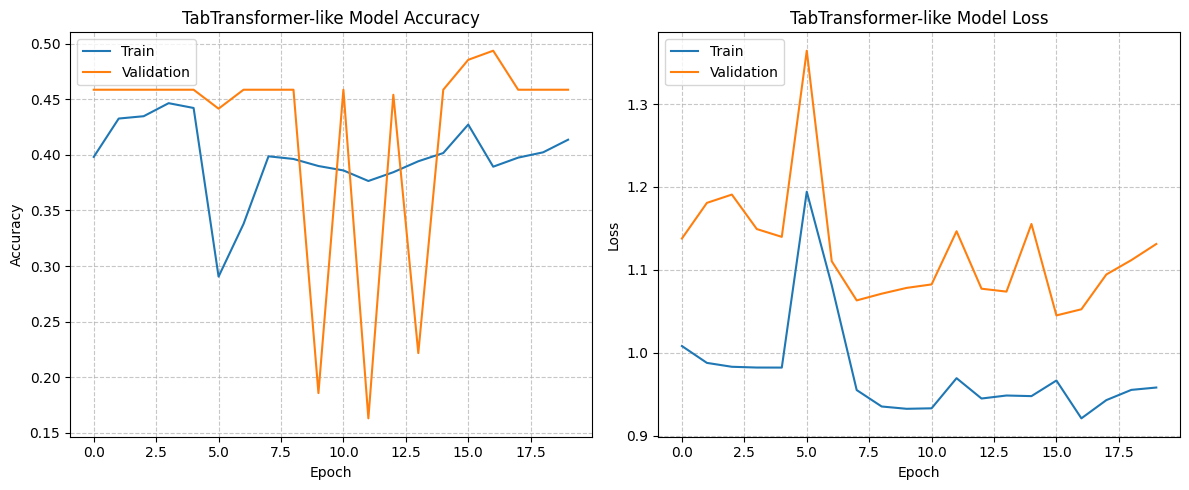


--- TabTransformer-like Model Performance ---
Test Accuracy: 0.4556
706/706 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
Classification Report for TabTransformer-like Model:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      2294
           1       0.13      1.00      0.23       292
           2       0.00      0.00      0.00     10000
           3       0.49      1.00      0.66     10000

    accuracy                           0.46     22586
   macro avg       0.16      0.50      0.22     22586
weighted avg       0.22      0.46      0.29     22586


TabTransformer-like Model Precision (weighted): 0.2190
TabTransformer-like Model Recall (weighted): 0.4556
TabTransformer-like Model F1 Score (weighted): 0.2945


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

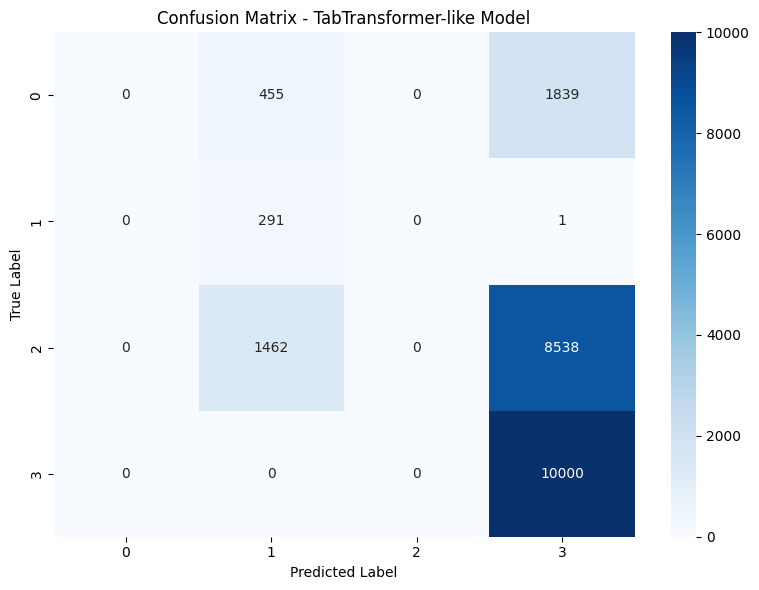

/tmp/ipykernel_14960/4218240784.py:35: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('jet', n_classes)(np.linspace(0, 1, n_classes))


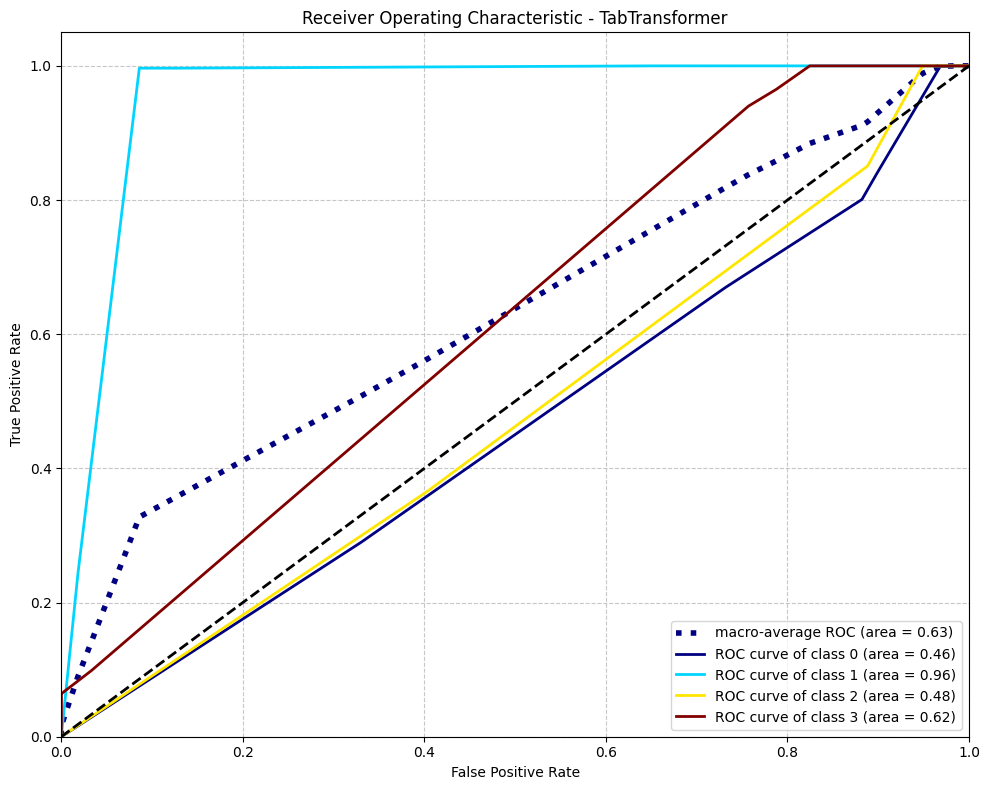


Updated model_performance with TabTransformer results:


,accuracy,precision,recall,f1_score,auc
LSTM,0.936535,0.939602,0.936535,0.936325,0.997445
ANN,0.966439,0.981210,0.966439,0.971338,0.996714
GRU,0.953688,0.956531,0.953688,0.953207,0.996980
hybrid(GRU-LSTM),0.950257,0.953311,0.950257,0.949749,0.995960
hybrid(GRU-ANN),0.927256,0.977400,0.927256,0.945939,0.989792
TFT,0.909192,0.963449,0.909192,0.926984,0.993048
Informer,0.897060,0.962438,0.897060,0.919364,0.991579
TabTransformer,0.455636,0.218974,0.455636,0.294505,0.628214


In [ ]:
print("\nTraining TabTransformer-like model...")

history_tabt = tabtransformer_model.fit(
    X_train_tabt, y_train_tabt,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1,
    class_weight=class_weights_dict # Apply class weights
)

print("TabTransformer-like model training complete!")

# Plot training history
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history_tabt.history['accuracy'])
plt.plot(history_tabt.history['val_accuracy'])
plt.title('TabTransformer-like Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_tabt.history['loss'])
plt.plot(history_tabt.history['val_loss'])
plt.title('TabTransformer-like Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Evaluate the model on the test set
loss_tabt, accuracy_tabt = tabtransformer_model.evaluate(X_test_tabt, y_test_tabt, verbose=0)
print(f"\n--- TabTransformer-like Model Performance ---")
print(f"Test Accuracy: {accuracy_tabt:.4f}")

y_pred_tabt_prob = tabtransformer_model.predict(X_test_tabt)
y_pred_tabt = np.argmax(y_pred_tabt_prob, axis=1)
y_true_tabt = np.argmax(y_test_tabt, axis=1)

print("Classification Report for TabTransformer-like Model:")
print(classification_report(y_true_tabt, y_pred_tabt))

# Calculate individual metrics
precision_tabt = precision_score(y_true_tabt, y_pred_tabt, average='weighted')
recall_tabt = recall_score(y_true_tabt, y_pred_tabt, average='weighted')
f1_tabt = f1_score(y_true_tabt, y_pred_tabt, average='weighted')

print(f"\nTabTransformer-like Model Precision (weighted): {precision_tabt:.4f}")
print(f"TabTransformer-like Model Recall (weighted): {recall_tabt:.4f}")
print(f"TabTransformer-like Model F1 Score (weighted): {f1_tabt:.4f}")

# Add TabTransformer performance to model_performance dictionary
model_performance['TabTransformer'] = {
    'accuracy': accuracy_tabt,
    'precision': precision_tabt,
    'recall': recall_tabt,
    'f1_score': f1_tabt
}

# Plot Confusion Matrix for TabTransformer
class_labels_tabt = [str(label) for label in sorted(np.unique(np.argmax(y_test_tabt, axis=1)))]

plt.figure(figsize=(8, 6))
cm_tabt = confusion_matrix(y_true_tabt, y_pred_tabt)
sns.heatmap(cm_tabt, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels_tabt, yticklabels=class_labels_tabt)
plt.title(f'Confusion Matrix - TabTransformer-like Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

# Calculate and plot ROC for TabTransformer
n_classes_tabt = y_test_tabt.shape[1]
fig_roc_tabt, ax_roc_tabt = plt.subplots(figsize=(10, 8))
auc_tabt = plot_roc_curve(y_test_tabt, y_pred_tabt_prob, 'TabTransformer', class_labels_tabt, n_classes_tabt, ax_roc_tabt)
plt.tight_layout()
plt.show()

# Update model_performance with AUC for TabTransformer
model_performance.loc['auc', 'TabTransformer'] = auc_tabt

print("\nUpdated model_performance with TabTransformer results:")
display(model_performance.T)

In [14]:
import time
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, GRU, LayerNormalization, MultiHeadAttention, Flatten, Reshape, GlobalAveragePooling1D
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
import numpy as np
import pandas as pd # Ensure pandas is imported for DataFrame if needed


def train_and_evaluate_model(
    model_builder_func, model_name, X_train, y_train, X_test, y_test,
    epochs=20, batch_size=32, class_weights=None
):
    print(f"\n--- Training and Evaluating {model_name} ---")

    # 1. Build and Compile Model
    model = model_builder_func()
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    # 2. Train Model and Measure Training Time
    start_train_time = time.time()
    history = model.fit(
        X_train, y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_split=0.1,
        verbose=0, # Suppress verbose output for multiple runs
        class_weight=class_weights
    )
    end_train_time = time.time()
    training_time = end_train_time - start_train_time

    # 3. Evaluate Model and Measure Inference Latency
    start_inference_time = time.time()
    y_pred_prob = model.predict(X_test, verbose=0)
    end_inference_time = time.time()
    inference_latency = (end_inference_time - start_inference_time) / X_test.shape[0] # Average per sample

    y_pred = np.argmax(y_pred_prob, axis=1)
    y_true = np.argmax(y_test, axis=1)

    # Calculate Metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    # Calculate AUC (using a direct calculation as plot_roc_curve involves plotting)
    n_classes = y_test.shape[1]
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_pred_prob[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= n_classes
    macro_auc = auc(all_fpr, mean_tpr)

    # Get model parameters
    total_params = model.count_params()

    results = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'auc': macro_auc,
        'training_time': training_time,
        'inference_latency_per_sample': inference_latency,
        'total_parameters': total_params
    }

    print(f"{model_name} Run Completed. Accuracy: {accuracy:.4f}, AUC: {macro_auc:.4f}")
    return results

# --- LSTM Model Builder ---
def build_lstm_model(input_shape, output_dim):
    model = Sequential([
        Input(shape=input_shape),
        LSTM(units=50, return_sequences=True),
        Dropout(0.2),
        LSTM(units=50, return_sequences=False),
        Dropout(0.2),
        Dense(units=output_dim, activation='softmax')
    ])
    return model

# --- ANN Model Builder ---
def build_ann_model(input_shape, output_dim):
    model = Sequential([
        Input(shape=input_shape),
        Dense(units=128, activation='relu'),
        Dropout(0.3),
        Dense(units=64, activation='relu'),
        Dropout(0.3),
        Dense(units=output_dim, activation='softmax')
    ])
    return model

# --- GRU Model Builder ---
def build_gru_model(input_shape, output_dim):
    model = Sequential([
        GRU(units=50, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        GRU(units=50, return_sequences=False),
        Dropout(0.2),
        Dense(units=output_dim, activation='softmax')
    ])
    return model

# --- Hybrid GRU-LSTM Model Builder ---
def build_hybrid_gru_lstm_model(input_shape, output_dim):
    model = Sequential([
        GRU(units=64, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        LSTM(units=64, return_sequences=False),
        Dropout(0.2),
        Dense(units=output_dim, activation='softmax')
    ])
    return model

# --- Hybrid GRU-ANN Model Builder ---
def build_hybrid_gru_ann_model(input_shape, output_dim):
    model = Sequential([
        Input(shape=input_shape),
        GRU(units=64, return_sequences=False),
        Dropout(0.2),
        Dense(units=64, activation='relu'),
        Dropout(0.2),
        Dense(units=output_dim, activation='softmax')
    ])
    return model

# --- Simplified TFT-like Model Builder ---
def build_tft_like_model(input_shape, output_dim,
                         head_size=32, num_heads=4, ff_dim=128,
                         num_transformer_blocks=1, mlp_units=[64, 32], dropout=0.1, mlp_dropout=0.1):
    inputs = Input(shape=input_shape)
    x = Dense(head_size * num_heads, activation="relu")(inputs)
    x = Dense(head_size * num_heads, activation="linear")(x)
    attention_input = Dense(head_size * num_heads)(x)
    multi_head_attention = MultiHeadAttention(
        num_heads=num_heads, key_dim=head_size, dropout=dropout
    )(attention_input, attention_input, attention_input)
    attention_output = LayerNormalization(epsilon=1e-6)(attention_input + multi_head_attention)
    ffn_output = Sequential([
        Dense(ff_dim, activation="relu"),
        Dense(head_size * num_heads),
    ])(attention_output)
    ffn_output = LayerNormalization(epsilon=1e-6)(attention_output + ffn_output)
    x = Flatten()(ffn_output)
    for unit in mlp_units:
        x = Dense(unit, activation="relu")(x)
        x = Dropout(mlp_dropout)(x)
    outputs = Dense(output_dim, activation="softmax")(x)
    return Model(inputs=inputs, outputs=outputs)

# --- Simplified Informer-like Model Builder ---
def build_informer_like_model(input_shape, output_dim, embed_dim=32, num_heads=4, ff_dim=64, dropout_rate=0.1):
    inputs = Input(shape=input_shape)
    x = inputs
    if input_shape[-1] != embed_dim:
        x = Dense(embed_dim)(x)
    attn_output = MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)(x, x)
    attn_output = Dropout(dropout_rate)(attn_output)
    attn_output = LayerNormalization(epsilon=1e-6)(x + attn_output)
    ffn_output = Dense(ff_dim, activation="relu")(attn_output)
    ffn_output = Dense(embed_dim)(ffn_output)
    ffn_output = Dropout(dropout_rate)(ffn_output)
    x = LayerNormalization(epsilon=1e-6)(attn_output + ffn_output)
    x = GlobalAveragePooling1D()(x)
    outputs = Dense(output_dim, activation="softmax")(x)
    return Model(inputs=inputs, outputs=outputs)

# --- Simplified TabTransformer-like Model Builder ---
def build_tabtransformer_like_model(num_features, output_dim,
                                     embed_dim=32, num_heads=4, ff_dim=64,
                                     num_transformer_blocks=2, dropout_rate=0.1,
                                     mlp_units=[128, 64]):
    inputs = Input(shape=(num_features,))
    x = Reshape((num_features, 1))(inputs)
    feature_embeddings = Dense(embed_dim)(x)
    transformer_input = feature_embeddings
    for _ in range(num_transformer_blocks):
        attn_output = MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)(
            transformer_input, transformer_input
        )
        attn_output = Dropout(dropout_rate)(attn_output)
        attn_output = LayerNormalization(epsilon=1e-6)(transformer_input + attn_output)
        ffn_output = Dense(ff_dim, activation="relu")(attn_output)
        ffn_output = Dense(embed_dim)(ffn_output)
        ffn_output = Dropout(dropout_rate)(ffn_output)
        transformer_input = LayerNormalization(epsilon=1e-6)(attn_output + ffn_output)
    x = Flatten()(transformer_input)
    for units in mlp_units:
        x = Dense(units, activation="relu")(x)
        x = Dropout(dropout_rate)(x)
    outputs = Dense(output_dim, activation="softmax")(x)
    return Model(inputs=inputs, outputs=outputs)


num_runs = 5 # Number of runs for each model
all_models_results = {}

# Prepare data for each model type
# LSTM/GRU/Hybrid models use X_reshaped (3D) and y_one_hot
# ANN uses X_scaled (2D) and y_one_hot
# TFT uses X_train_tft_reshaped, X_test_tft_reshaped, y_train_tft, y_test_tft
# Informer uses X_train_informer_reshaped, X_test_informer_reshaped, y_train_informer, y_test_informer
# TabTransformer uses X_train_tabt, X_test_tabt, y_train_tabt, y_test_tabt

# Reuse existing splits for consistency and to avoid re-running expensive data prep
X_train_rnn, X_test_rnn, y_train_rnn, y_test_rnn = X_train_lstm, X_test_lstm, y_train_lstm, y_test_lstm

# Data for ANN model - explicitly define here
X_train_ann, X_test_ann, y_train_ann, y_test_ann = train_test_split(
    X_scaled, y_one_hot, test_size=0.2, random_state=42, stratify=np.argmax(y_one_hot, axis=1)
)
X_train_ann_2d, X_test_ann_2d, y_train_ann_2d, y_test_ann_2d = X_train_ann, X_test_ann, y_train_ann, y_test_ann

# Data for TFT model - explicitly define and reshape here
X_train_tft, X_test_tft, y_train_tft, y_test_tft = train_test_split(
    X_scaled, y_one_hot, test_size=0.2, random_state=42, stratify=np.argmax(y_one_hot, axis=1)
)
timesteps = 1 # Each sample is a single observation in this tabular context
input_dim = X_train_tft.shape[1] # Number of features
X_train_tft_reshaped = X_train_tft.reshape(-1, timesteps, input_dim)
X_test_tft_reshaped = X_test_tft.reshape(-1, timesteps, input_dim)
X_train_tft_run, X_test_tft_run, y_train_tft_run, y_test_tft_run = X_train_tft_reshaped, X_test_tft_reshaped, y_train_tft, y_test_tft

# Data for Informer model - explicitly define and reshape here
X_train_informer, X_test_informer, y_train_informer, y_test_informer = train_test_split(
    X_scaled, y_one_hot, test_size=0.2, random_state=42, stratify=np.argmax(y_one_hot, axis=1)
)
sequence_length = X_train_informer.shape[1] # Each feature is a 'step'
input_features = 1 # Each step has 1 feature (the scaled value)
X_train_informer_reshaped = X_train_informer.reshape(-1, sequence_length, input_features)
X_test_informer_reshaped = X_test_informer.reshape(-1, sequence_length, input_features)
X_train_informer_run, X_test_informer_run, y_train_informer_run, y_test_informer_run = X_train_informer_reshaped, X_test_informer_reshaped, y_train_informer, y_test_informer

# Data for TabTransformer model - explicitly define here
X_train_tabt, X_test_tabt, y_train_tabt, y_test_tabt = train_test_split(
    X_balanced, y_one_hot, test_size=0.2, random_state=42, stratify=np.argmax(y_one_hot, axis=1)
)
X_train_tabt_run, X_test_tabt_run, y_train_tabt_run, y_test_tabt_run = X_train_tabt, X_test_tabt, y_train_tabt, y_test_tabt


# Define a dictionary of models and their associated data and builder functions
models_to_run = {
    'LSTM': {
        'builder': lambda: build_lstm_model(input_shape=(X_train_rnn.shape[1], 1), output_dim=y_train_rnn.shape[1]),
        'X_train': X_train_rnn, 'y_train': y_train_rnn, 'X_test': X_test_rnn, 'y_test': y_test_rnn
    },
    'ANN': {
        'builder': lambda: build_ann_model(input_shape=(X_train_ann_2d.shape[1],), output_dim=y_train_ann_2d.shape[1]),
        'X_train': X_train_ann_2d, 'y_train': y_train_ann_2d, 'X_test': X_test_ann_2d, 'y_test': y_test_ann_2d
    },
    'GRU': {
        'builder': lambda: build_gru_model(input_shape=(X_train_rnn.shape[1], 1), output_dim=y_train_rnn.shape[1]),
        'X_train': X_train_rnn, 'y_train': y_train_rnn, 'X_test': X_test_rnn, 'y_test': y_test_rnn
    },
    'hybrid(GRU-LSTM)': {
        'builder': lambda: build_hybrid_gru_lstm_model(input_shape=(X_train_rnn.shape[1], 1), output_dim=y_train_rnn.shape[1]),
        'X_train': X_train_rnn, 'y_train': y_train_rnn, 'X_test': X_test_rnn, 'y_test': y_test_rnn
    },
    'hybrid(GRU-ANN)': {
        'builder': lambda: build_hybrid_gru_ann_model(input_shape=(X_train_rnn.shape[1], 1), output_dim=y_train_rnn.shape[1]),
        'X_train': X_train_rnn, 'y_train': y_train_rnn, 'X_test': X_test_rnn, 'y_test': y_test_rnn
    },
    'TFT': {
        'builder': lambda: build_tft_like_model(input_shape=X_train_tft_run.shape[1:], output_dim=y_train_tft_run.shape[1]),
        'X_train': X_train_tft_run, 'y_train': y_train_tft_run, 'X_test': X_test_tft_run, 'y_test': y_test_tft_run
    },
    'Informer': {
        'builder': lambda: build_informer_like_model(input_shape=X_train_informer_run.shape[1:], output_dim=y_train_informer_run.shape[1]),
        'X_train': X_train_informer_run, 'y_train': y_train_informer_run, 'X_test': X_test_informer_run, 'y_test': y_test_informer_run
    },
    'TabTransformer': {
        'builder': lambda: build_tabtransformer_like_model(
            num_features=X_train_tabt_run.shape[1], output_dim=y_train_tabt_run.shape[1]
        ),
        'X_train': X_train_tabt_run, 'y_train': y_train_tabt_run, 'X_test': X_test_tabt_run, 'y_test': y_test_tabt_run
    }
}

# Loop through each model, run multiple times, and collect results
for model_name, model_info in models_to_run.items():
    print(f"\nProcessing {model_name} Model...")
    model_results = []
    for i in range(num_runs):
        print(f"  {model_name} - Run {i+1}/{num_runs}")
        results = train_and_evaluate_model(
            model_info['builder'],
            model_name,
            model_info['X_train'],
            model_info['y_train'],
            model_info['X_test'],
            model_info['y_test'],
            class_weights=class_weights_dict
        )
        model_results.append(results)
    all_models_results[model_name] = model_results

print("\nAll model runs complete. Aggregating results...")


Processing LSTM Model...
  LSTM - Run 1/5

--- Training and Evaluating LSTM ---
LSTM Run Completed. Accuracy: 0.9820, AUC: 0.9971
  LSTM - Run 2/5

--- Training and Evaluating LSTM ---
LSTM Run Completed. Accuracy: 0.9484, AUC: 0.9927
  LSTM - Run 3/5

--- Training and Evaluating LSTM ---
LSTM Run Completed. Accuracy: 0.9754, AUC: 0.9973
  LSTM - Run 4/5

--- Training and Evaluating LSTM ---
LSTM Run Completed. Accuracy: 0.9660, AUC: 0.9975
  LSTM - Run 5/5

--- Training and Evaluating LSTM ---
LSTM Run Completed. Accuracy: 0.9743, AUC: 0.9970

Processing ANN Model...
  ANN - Run 1/5

--- Training and Evaluating ANN ---
ANN Run Completed. Accuracy: 0.9755, AUC: 0.9969
  ANN - Run 2/5

--- Training and Evaluating ANN ---
ANN Run Completed. Accuracy: 0.9759, AUC: 0.9966
  ANN - Run 3/5

--- Training and Evaluating ANN ---
ANN Run Completed. Accuracy: 0.9659, AUC: 0.9966
  ANN - Run 4/5

--- Training and Evaluating ANN ---
ANN Run Completed. Accuracy: 0.9654, AUC: 0.9963
  ANN - Run 5/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


GRU Run Completed. Accuracy: 0.9669, AUC: 0.9964
  GRU - Run 2/5

--- Training and Evaluating GRU ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


GRU Run Completed. Accuracy: 0.9666, AUC: 0.9968
  GRU - Run 3/5

--- Training and Evaluating GRU ---


...

TFT Run Completed. Accuracy: 0.9525, AUC: 0.9963
  TFT - Run 4/5

--- Training and Evaluating TFT ---


/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis 3 of a tensor of shape (None, 4, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis 3 of a tensor of shape (32, 4, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


TFT Run Completed. Accuracy: 0.9140, AUC: 0.9959
  TFT - Run 5/5

--- Training and Evaluating TFT ---


/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis 3 of a tensor of shape (None, 4, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis 3 of a tensor of shape (32, 4, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


TFT Run Completed. Accuracy: 0.9006, AUC: 0.9918

Processing Informer Model...
  Informer - Run 1/5

--- Training and Evaluating Informer ---
Informer Run Completed. Accuracy: 0.9043, AUC: 0.9944
  Informer - Run 2/5

--- Training and Evaluating Informer ---
Informer Run Completed. Accuracy: 0.9038, AUC: 0.9948
  Informer - Run 3/5

--- Training and Evaluating Informer ---
Informer Run Completed. Accuracy: 0.9412, AUC: 0.9928
  Informer - Run 4/5

--- Training and Evaluating Informer ---
Informer Run Completed. Accuracy: 0.9130, AUC: 0.9934
  Informer - Run 5/5

--- Training and Evaluating Informer ---
Informer Run Completed. Accuracy: 0.9169, AUC: 0.9940

Processing TabTransformer Model...
  TabTransformer - Run 1/5

--- Training and Evaluating TabTransformer ---
TabTransformer Run Completed. Accuracy: 0.4556, AUC: 0.5891
  TabTransformer - Run 2/5

--- Training and Evaluating TabTransformer ---
TabTransformer Run Completed. Accuracy: 0.4556, AUC: 0.6111
  TabTransformer - Run 3/5

--

In [ ]:
import pandas as pd
import numpy as np

print("Aggregating results from multiple runs...")

# Initialize a dictionary to store aggregated results
aggregated_results = {}

# Iterate through each model's results
for model_name, results_list in all_models_results.items():
    if not results_list: # Skip if no results for the model (shouldn't happen if runs completed)
        continue

    # Convert list of dictionaries to a DataFrame for easy aggregation
    df_results = pd.DataFrame(results_list)

    # Calculate mean and standard deviation for each metric
    mean_metrics = df_results.mean().to_dict()
    std_metrics = df_results.std().to_dict()

    # Store aggregated results
    aggregated_results[model_name] = {
        'mean': mean_metrics,
        'std': std_metrics
    }

# --- Display Aggregated Performance Metrics (Mean and Std Dev) ---
print("\n--- Aggregated Model Performance (Mean ± Std Dev) ---")

# Create a DataFrame for displaying mean results
mean_df_data = {metric: [aggregated_results[model]['mean'][metric] for model in aggregated_results]
                for metric in aggregated_results[list(aggregated_results.keys())[0]]['mean'].keys()}
mean_df = pd.DataFrame(mean_df_data, index=aggregated_results.keys())

# Create a DataFrame for displaying std dev results
std_df_data = {metric: [aggregated_results[model]['std'][metric] for model in aggregated_results]
               for metric in aggregated_results[list(aggregated_results.keys())[0]]['std'].keys()}
std_df = pd.DataFrame(std_df_data, index=aggregated_results.keys())

# Format and display combined mean ± std dev
combined_df = pd.DataFrame(index=mean_df.index, columns=mean_df.columns)
for col in mean_df.columns:
    if col not in ['total_parameters']:
        combined_df[col] = mean_df[col].round(4).astype(str) + ' ± ' + std_df[col].round(4).astype(str)
    else:
        # Parameters don't change per run, so just show the mean (which is the value)
        combined_df[col] = mean_df[col].round(0).astype(int).astype(str)

display(combined_df)

print("\nResults aggregation complete. Now we can proceed with statistical significance tests and ablation studies.")